<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/Transformer_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Transformer 완전 정복

## 🎯 이 노트북에서 무엇을 배울까요?

여러분이 매일 사용하는 **ChatGPT, 파파고, 구글 번역, AI 음성 비서**의 핵심 두뇌는 모두 **Transformer**라는 기술입니다.

이 노트북은 차근차근 따라오면 **이 마법 같은 기술의 원리를 직접 코드로 만들어 볼 수 있도록** 설계되었습니다.

---

### 📚 학습 로드맵

```
1️⃣ 환경 설정          → 도구 준비하기
2️⃣ Token Embedding   → "단어를 숫자로 변환하기"
3️⃣ Positional Encoding → "순서 정보 알려주기"
4️⃣ Attention         → "중요한 단어에 집중하기"
5️⃣ Multi-Head       → "여러 관점으로 보기"
6️⃣ FFN & Norm       → "생각을 정리하기"
7️⃣ Encoder          → "이해하는 부분"
8️⃣ Decoder          → "말하는 부분"
9️⃣ 전체 Transformer → "조립 완성!"
🔟 번역 실습         → "직접 학습시켜보기"
1️⃣1️⃣ Attention 시각화 → "AI의 생각 들여다보기"
1️⃣2️⃣ 현대 LLM 기술  → "최신 트렌드 살펴보기"
```

---

### 💡 학습 팁

- 🟦 **개념 설명** 부분을 천천히 읽어보세요
- 🟨 **코드 셀**은 차례대로 실행해보세요 (`Shift + Enter`)
- 🟩 **빈칸 채우기 실습** 으로 직접 작성해보세요
- 🟪 **퀴즈** 로 이해도를 점검하세요
- 📊 **시각화** 로 눈으로 확인하세요

---

### 🔧 시작하기 전에

> **Colab 사용자**: 상단 메뉴에서 `런타임 > 런타임 유형 변경 > T4 GPU` 선택을 권장합니다.
> GPU가 없어도 실행되지만, 일부 실습은 좀 느릴 수 있어요.

> **본 노트북은 차근차근 순서대로 실행해야 합니다.** 위에서부터 한 셀씩 실행하세요!


---

## 🌟 시작 전 잠깐! Transformer가 도대체 뭔가요?

### 🤔 일상 속의 Transformer

여러분이 사용하는 이런 서비스들의 핵심에 Transformer가 있어요:

| 서비스 | 사용 예시 | 어떤 일을 할까? |
|--------|----------|---------------|
| 💬 **ChatGPT** | "파이썬 문법 알려줘" | 질문을 이해하고 답변 생성 |
| 🌐 **구글 번역** | "Hello → 안녕하세요" | 한 언어를 다른 언어로 |
| 📧 **이메일 자동완성** | "감사" → "감사합니다" | 다음 단어 예측 |
| 🎵 **음악 생성** | 멜로디 만들기 | 다음 음표 예측 |
| 🖼️ **이미지 캡션** | 사진 → 설명문 | 이미지 이해 |

### 🧩 비유: Transformer는 "뇌의 회의실"

Transformer를 **8명의 전문가가 모인 회의실**이라고 상상해보세요:

```
"나는 학교에 간다" 라는 문장이 들어오면...

   👨‍🏫 전문가1: "주어를 찾아볼게요!" → '나는'에 집중
   👩‍🔬 전문가2: "동사를 찾아볼게요!" → '간다'에 집중  
   👨‍💼 전문가3: "장소를 찾아볼게요!" → '학교에'에 집중
   ...
   
모두의 의견을 종합해서 "I go to school"이라고 번역!
```

이렇게 **여러 관점에서 동시에 분석**하는 것이 Transformer의 핵심입니다.

### 📖 역사적 배경

- 📅 **2017년 6월**: Google이 "Attention Is All You Need" 논문 발표
- 🚀 **2018년**: BERT, GPT 등장 (Transformer 기반)
- ⭐ **2022년 11월**: ChatGPT 등장 → AI 혁명 시작
- 🔥 **현재**: 거의 모든 AI가 Transformer 사용

### 🎬 자, 이제 직접 만들어봅시다!


---

# 1️⃣ 환경 설정 (도구 준비하기)

## 🛠️ 왜 이런 라이브러리가 필요한가요?

요리하기 전에 도구를 준비하는 것처럼, 코드를 작성하기 전에 필요한 도구(라이브러리)들을 불러와야 해요.

| 라이브러리 | 역할 | 비유 |
|-----------|------|------|
| `torch` (PyTorch) | AI 모델을 만드는 핵심 도구 | 🔪 칼 (가장 중요한 요리 도구) |
| `numpy` | 숫자 계산 도구 | 🧮 계산기 |
| `matplotlib` | 그래프 그리기 | 📊 도화지 |
| `seaborn` | 예쁜 그래프 그리기 | 🎨 색연필 |
| `math` | 수학 함수 (sin, cos 등) | 📐 자와 컴퍼스 |

### 💡 PyTorch란?
- Facebook(Meta)이 만든 **딥러닝 프레임워크**
- 텐서(Tensor)라는 **다차원 배열**을 다룸
- GPU를 활용해 빠르게 계산 가능


In [1]:
# === 1단계: 필요한 라이브러리 모두 불러오기 ===
import torch
import torch.nn as nn              # 신경망 레이어 (Linear, Embedding 등)
import torch.nn.functional as F    # 활성화 함수 (softmax, relu 등)
import torch.optim as optim        # 옵티마이저 (Adam 등)
import math                        # 수학 함수
import numpy as np                 # 숫자 배열 계산
import matplotlib.pyplot as plt    # 그래프
import matplotlib.font_manager as fm
from matplotlib import rcParams
import seaborn as sns              # 예쁜 그래프
import copy
import warnings
warnings.filterwarnings('ignore')

print('✅ 라이브러리를 모두 불러왔습니다!')


✅ 라이브러리를 모두 불러왔습니다!


In [2]:
# === 2단계: 한글 폰트 설정 (그래프에 한글이 깨지지 않게) ===
# Colab 환경에서는 한글 폰트가 기본 설치되어 있지 않아 직접 설치합니다.
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1

fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
rcParams['font.family'] = fe.name
rcParams['axes.unicode_minus'] = False

print('✅ 한글 폰트 설정 완료!')


✅ 한글 폰트 설정 완료!


In [3]:
# === 3단계: GPU 사용 가능 여부 확인 ===
# GPU가 있으면 훨씬 빠르게 계산할 수 있어요 (대략 10~100배!)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'📦 PyTorch 버전: {torch.__version__}')
print(f'💻 사용 디바이스: {device}')

if torch.cuda.is_available():
    print(f'🚀 GPU 모델: {torch.cuda.get_device_name(0)}')
    print(f'   → 빠르게 학습할 수 있어요!')
else:
    print(f'🐢 GPU가 없어요. CPU로 진행합니다 (조금 느릴 수 있어요)')
    print(f'   → Colab: 런타임 > 런타임 유형 변경 > T4 GPU')

# 시드 고정: 같은 결과 재현을 위해
torch.manual_seed(42)
np.random.seed(42)
print(f'\n🎲 랜덤 시드 고정 (42) - 매번 같은 결과를 얻어요')


📦 PyTorch 버전: 2.10.0+cu128
💻 사용 디바이스: cuda
🚀 GPU 모델: Tesla T4
   → 빠르게 학습할 수 있어요!

🎲 랜덤 시드 고정 (42) - 매번 같은 결과를 얻어요


### ✅ 체크포인트 1
- [ ] 라이브러리가 모두 import 되었나요?
- [ ] GPU 또는 CPU 정보가 출력되었나요?
- [ ] 오류 메시지가 없나요?

**문제가 있다면**: 셀을 처음부터 다시 실행해보세요 (`런타임 > 모든 셀 실행`)


---

# 2️⃣ Token Embedding — 단어를 숫자로 바꾸기

## 🤔 컴퓨터는 어떻게 단어를 이해할까요?

컴퓨터는 **숫자만 알아듣습니다**. 그럼 "사과", "바나나" 같은 단어는 어떻게 처리할까요?

### 💡 핵심 아이디어: 단어 → 좌표

비유하자면, **세상의 모든 단어를 거대한 지도 위의 점**으로 표현합니다.

```
        💛 (귀여운, 1)
        🐶 강아지
       /
      / (비슷한 의미는 가깝게)
     /
    🐱 고양이
   /
  /
 🍎 사과 --------- 🍌 바나나
                   |
                   |
                   🚗 자동차 (의미가 다르면 멀리)
```

- 비슷한 의미의 단어 → 좌표가 **가깝게**
- 다른 의미의 단어 → 좌표가 **멀리**

이런 좌표를 **임베딩 벡터(Embedding Vector)** 라고 합니다.

### 📐 실제 Transformer에서는?

- 한 단어 = **512차원의 좌표** (원본 논문 기준)
- 즉, 한 단어는 512개의 숫자로 표현됨
- 처음에는 랜덤 좌표 → 학습하면서 의미 있는 좌표로 변화


In [4]:
# === 직관 잡기: 단어를 좌표(벡터)로 표현하기 ===
# 간단한 예시로 시작해봅시다. (실제로는 512차원이지만, 여기선 4차원만)

# 가상의 임베딩 벡터 (학습 후 모습이라고 가정)
word_embeddings = {
    '강아지':  [0.8, 0.7, 0.1, 0.2],   # 동물 + 귀여움
    '고양이':  [0.7, 0.8, 0.2, 0.1],   # 동물 + 귀여움 (강아지와 비슷)
    '사과':    [0.1, 0.2, 0.8, 0.7],   # 과일 + 빨강
    '바나나':  [0.2, 0.1, 0.7, 0.8],   # 과일 + 노랑
    '자동차':  [0.9, 0.1, 0.1, 0.1],   # 기계, 빠름
}

# 단어 간 유사도를 계산해봅시다 (코사인 유사도)
import numpy as np

def 유사도(단어1, 단어2):
    v1 = np.array(word_embeddings[단어1])
    v2 = np.array(word_embeddings[단어2])
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    # 두 벡터 방향 사이의 각도 구하기
    # norm 피타고라스 정리 이용해서 벡터의 방향 구하기

print('🔍 단어 간 유사도 (1에 가까울수록 비슷한 의미)')
print('=' * 45)
print(f'  강아지 ↔ 고양이: {유사도("강아지", "고양이"):.3f}  (둘 다 동물 → 비슷!)')
print(f'  사과 ↔ 바나나:   {유사도("사과", "바나나"):.3f}  (둘 다 과일 → 비슷!)')
print(f'  강아지 ↔ 사과:   {유사도("강아지", "사과"):.3f}  (동물 vs 과일 → 다름)')
print(f'  강아지 ↔ 자동차: {유사도("강아지", "자동차"):.3f}  (살아있음 vs 기계 → 다름)')


🔍 단어 간 유사도 (1에 가까울수록 비슷한 의미)
  강아지 ↔ 고양이: 0.983  (둘 다 동물 → 비슷!)
  사과 ↔ 바나나:   0.983  (둘 다 과일 → 비슷!)
  강아지 ↔ 사과:   0.373  (동물 vs 과일 → 다름)
  강아지 ↔ 자동차: 0.824  (살아있음 vs 기계 → 다름)


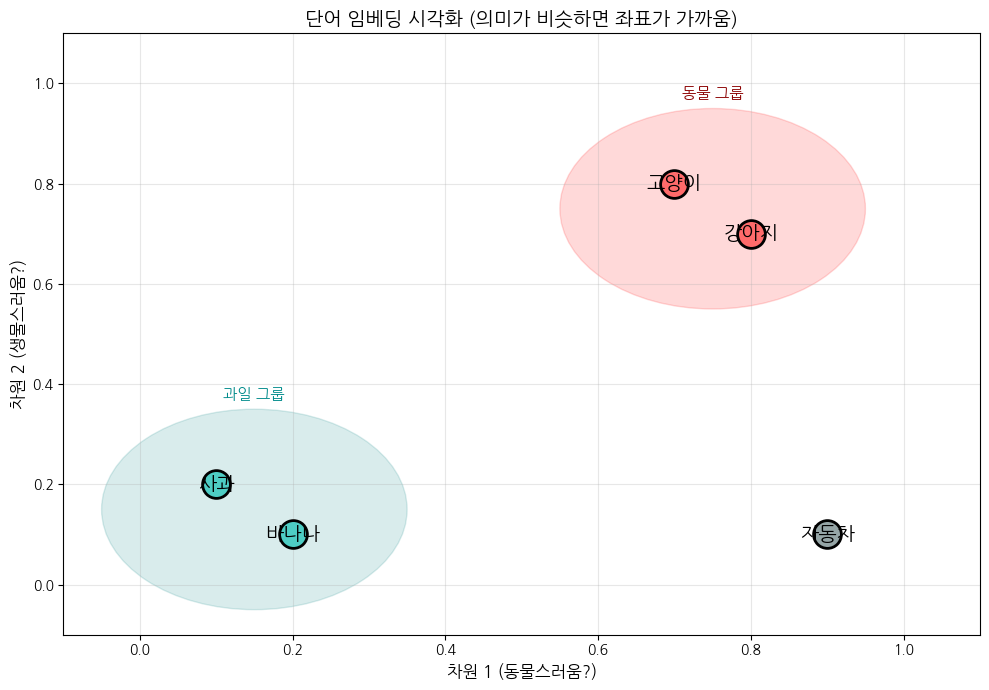

💡 의미가 비슷한 단어들이 같은 영역에 모여있죠?
💡 실제로는 512차원이지만, 원리는 똑같습니다!


In [5]:
# === 시각화: 단어 임베딩을 2D 평면에 표시하기 ===
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'강아지': '#FF6B6B', '고양이': '#FF6B6B',  # 동물 = 빨강
          '사과': '#4ECDC4', '바나나': '#4ECDC4',    # 과일 = 청록
          '자동차': '#95A5A6'}                       # 기계 = 회색

for 단어, 벡터 in word_embeddings.items():
    # 4차원 중 처음 2차원만 사용
    x, y = 벡터[0], 벡터[1]
    ax.scatter(x, y, s=400, c=colors[단어], edgecolors='black', linewidth=2, zorder=3)
    ax.annotate(단어, (x, y), fontsize=14, fontweight='bold',
                ha='center', va='center', zorder=4)

ax.set_xlabel('차원 1 (동물스러움?)', fontsize=12)
ax.set_ylabel('차원 2 (생물스러움?)', fontsize=12)
ax.set_title('단어 임베딩 시각화 (의미가 비슷하면 좌표가 가까움)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

# 그룹 표시
from matplotlib.patches import Ellipse
ax.add_patch(Ellipse((0.75, 0.75), 0.4, 0.4, color='red', alpha=0.15))
ax.text(0.75, 0.97, '동물 그룹', ha='center', fontsize=11, color='darkred')

ax.add_patch(Ellipse((0.15, 0.15), 0.4, 0.4, color='teal', alpha=0.15))
ax.text(0.15, 0.37, '과일 그룹', ha='center', fontsize=11, color='darkcyan')

plt.tight_layout()
plt.show()
print('💡 의미가 비슷한 단어들이 같은 영역에 모여있죠?')
print('💡 실제로는 512차원이지만, 원리는 똑같습니다!')


## 🏗️ PyTorch로 Token Embedding 만들기

이제 실제 PyTorch 코드로 Embedding 레이어를 만들어봅시다.

### 핵심 개념
1. **Vocabulary(어휘)**: 사용할 모든 단어 목록 (예: 100개의 단어)
2. **각 단어에 번호 부여**: '강아지'=0, '고양이'=1, '사과'=2, ...
3. **번호 → 벡터로 변환**: 0번 → [0.8, 0.7, ...] (512차원)
4. **`√d_model` 곱하기**: 값이 너무 작아지지 않도록 스케일 조정

### 🤓 왜 √d_model 을 곱할까?
- 512차원의 평균값이 너무 작으면 → 위치 인코딩(다음 섹션)이 묻혀버려요
- 그래서 √512 ≈ 22.6 을 곱해서 값을 키워줘요
- 이렇게 하면 임베딩과 위치 인코딩의 크기가 비슷해져요


In [6]:
# === Token Embedding 클래스 만들기 ===
class TokenEmbedding(nn.Module):
    """
    토큰(단어 번호) → 임베딩 벡터(d_model 차원의 좌표) 변환

    예시:
        입력: [10, 25, 42, 7]          (4개의 단어 번호)
        출력: 4 × 512 크기의 행렬     (각 단어를 512차원 좌표로)
    """
    def __init__(self, vocab_size, d_model):
        super().__init__()
        # nn.Embedding: 룩업 테이블 (단어 번호 → 벡터)
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        # √d_model 스케일링 (위에서 설명한 이유 때문)
        return self.embedding(x) * math.sqrt(self.d_model)


# === 실습: 직접 사용해봅시다 ===
vocab_size = 100  # 어휘 크기 (사용할 단어 종류 100개)
d_model = 512     # 한 단어를 512차원 벡터로 표현

embed = TokenEmbedding(vocab_size, d_model)

# 예시 문장 "나는 학교에 간다 [EOS]" → 단어 번호로 변환했다고 가정
# (실제로는 토크나이저가 자동으로 해줍니다)
sample_tokens = torch.tensor([[10, 25, 42, 7]])  # (1개 문장, 4개 단어)

# Embedding 통과
embedded = embed(sample_tokens)

print(f'📥 입력 형태:  {sample_tokens.shape}')
print(f'    → 의미: (배치(문장 수)=1, 단어수=4)')
print(f'\n📤 출력 형태: {embedded.shape}')
print(f'    → 의미: (배치=1, 단어수=4, 차원=512)')
print(f'\n🔢 첫 번째 단어 벡터 (앞 10차원만 미리보기):')
print(f'   {embedded[0, 0, :10].detach().numpy().round(3)}')
print(f'\n💡 한 단어가 512개의 숫자(좌표)로 표현됩니다!')


📥 입력 형태:  torch.Size([1, 4])
    → 의미: (배치(문장 수)=1, 단어수=4)

📤 출력 형태: torch.Size([1, 4, 512])
    → 의미: (배치=1, 단어수=4, 차원=512)

🔢 첫 번째 단어 벡터 (앞 10차원만 미리보기):
   [ 14.966  -0.746  -3.167  23.211 -44.615  13.572  30.799  -3.916  17.096
  -3.312]

💡 한 단어가 512개의 숫자(좌표)로 표현됩니다!


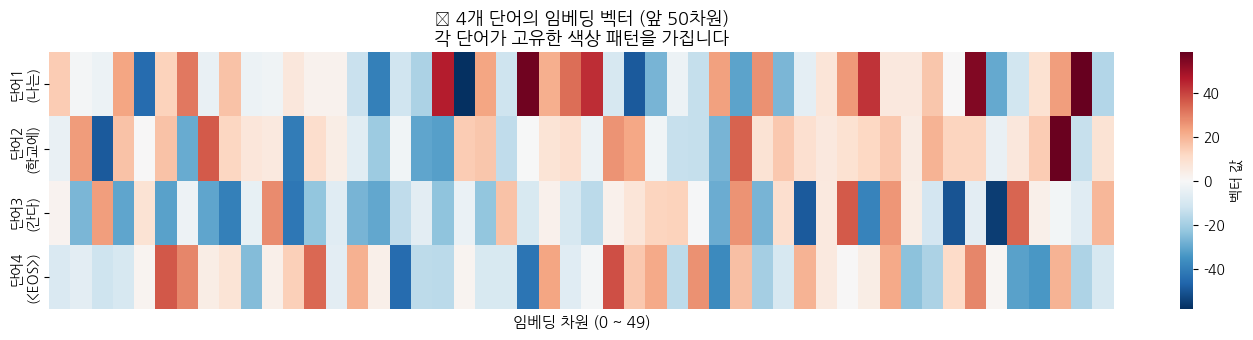

📊 위 그림 해석:
   • 가로축: 임베딩의 차원 (0~49)
   • 세로축: 각 단어
   • 색깔: 빨강(+) ↔ 흰색(0) ↔ 파랑(-)
   • 각 단어마다 색상 패턴이 다르죠? → 고유한 좌표!


In [7]:
# === 시각화: 임베딩 벡터를 색상으로 표현 (히트맵) ===
fig, ax = plt.subplots(figsize=(14, 3.5))

sns.heatmap(
    embedded[0].detach().numpy()[:, :50],  # 처음 50차원만
    cmap='RdBu_r', center=0, ax=ax,
    xticklabels=False,
    yticklabels=['단어1\n(나는)', '단어2\n(학교에)',
                 '단어3\n(간다)', '단어4\n(<EOS>)'],
    cbar_kws={'label': '벡터 값'}
)
ax.set_title('🎨 4개 단어의 임베딩 벡터 (앞 50차원)\n각 단어가 고유한 색상 패턴을 가집니다',
             fontsize=13, fontweight='bold')
ax.set_xlabel('임베딩 차원 (0 ~ 49)', fontsize=11)
plt.tight_layout()
plt.show()

print('📊 위 그림 해석:')
print('   • 가로축: 임베딩의 차원 (0~49)')
print('   • 세로축: 각 단어')
print('   • 색깔: 빨강(+) ↔ 흰색(0) ↔ 파랑(-)')
print('   • 각 단어마다 색상 패턴이 다르죠? → 고유한 좌표!')


## 🎯 빈칸 채우기 실습 #1

아래 코드를 직접 완성해서 **자신만의 임베딩**을 만들어보세요!

### 미션: 어휘 크기 50, 차원 256짜리 임베딩을 만들고, 3개 단어를 변환해보기


In [8]:
# === ✏️ 빈칸 채우기 실습 #1 ===
# TODO: 아래 빈칸(______)을 채워주세요!

# 1) 어휘 크기 50, 차원 256짜리 Embedding 만들기
my_vocab_size = 50  # 힌트: 50
my_d_model = 256     # 힌트: 256

my_embed = TokenEmbedding(my_vocab_size, my_d_model)

# 2) 3개 단어로 이루어진 문장 텐서 만들기 (배치 크기 1)
#    단어 번호는 자유롭게! 단, vocab_size보다 작아야 해요
my_tokens = torch.tensor([[7, 13, 33]])  # 힌트: [5, 12, 30] 같이

# 3) Embedding 통과
my_output = my_embed(my_tokens)  # 힌트: my_tokens 넣기

# 4) 결과 확인
print(f'어휘 크기:    {my_vocab_size}')
print(f'임베딩 차원:  {my_d_model}')
print(f'입력 형태:    {my_tokens.shape}')
print(f'출력 형태:    {my_output.shape}')
print(f'\n예상 출력 형태: (1, 3, 256)')


어휘 크기:    50
임베딩 차원:  256
입력 형태:    torch.Size([1, 3])
출력 형태:    torch.Size([1, 3, 256])

예상 출력 형태: (1, 3, 256)


<details>
<summary>🔑 정답 보기 (먼저 직접 풀어보세요!)</summary>

```python
my_vocab_size = 50
my_d_model = 256
my_embed = TokenEmbedding(my_vocab_size, my_d_model)
my_tokens = torch.tensor([[5, 12, 30]])
my_output = my_embed(my_tokens)
```
</details>

## 🧠 퀴즈 #1
1. **임베딩 벡터의 차원 수가 늘어나면 어떤 일이 생길까요?**
   - (a) 단어를 더 정교하게 표현할 수 있다
   - (b) 메모리를 더 많이 사용한다
   - (c) 둘 다 맞다 ← 정답!

2. **`vocab_size`를 100으로 설정했는데 입력에 `tensor([[150]])`을 넣으면?**
   - 오류 발생! 어휘에 없는 번호이기 때문이에요.


---

# 3️⃣ Positional Encoding — 순서 정보 알려주기

## 🤔 왜 위치 정보가 필요할까?

다음 두 문장을 비교해보세요:

| 문장 | 의미 |
|------|------|
| 🐶 **"나는 너를 좋아해"** | 내가 너를 좋아함 |
| 🐱 **"너는 나를 좋아해"** | 네가 나를 좋아함 |

**같은 단어들로 이루어져 있지만, 의미가 완전히 달라요!** 😱

순서가 다르기 때문이죠. 그런데...

### 😨 큰 문제!
Transformer는 단어들을 **동시에 한꺼번에** 처리합니다 (병렬 처리).
즉, "어느 단어가 먼저였는지" 모릅니다. 어떡하죠?

### 💡 해결책: 단어마다 "좌석 번호"를 주자!

영화관 좌석을 떠올려보세요:
- A1, A2, A3, ... 처럼 각 자리에 고유한 번호가 있죠?
- 마찬가지로, 각 단어 위치에 **고유한 패턴의 숫자**를 더해줍시다!

### 🎵 어떤 패턴을 사용할까? → 사인(sin)과 코사인(cos) 곡선!

음악의 음표처럼, 각 위치마다 다른 음(파형)을 부여합니다.

```
위치 0: ▁▂▃▄ (특정 패턴)
위치 1: ▂▃▄▅ (다른 패턴)
위치 2: ▃▄▅▆ (또 다른 패턴)
...
```

### 📐 수식 (어려워 보여도 코드로 보면 쉬워요!)

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- `pos`: 단어의 위치 (0, 1, 2, 3, ...)
- `i`: 차원 번호
- **짝수 차원**은 `sin`, **홀수 차원**은 `cos` 사용


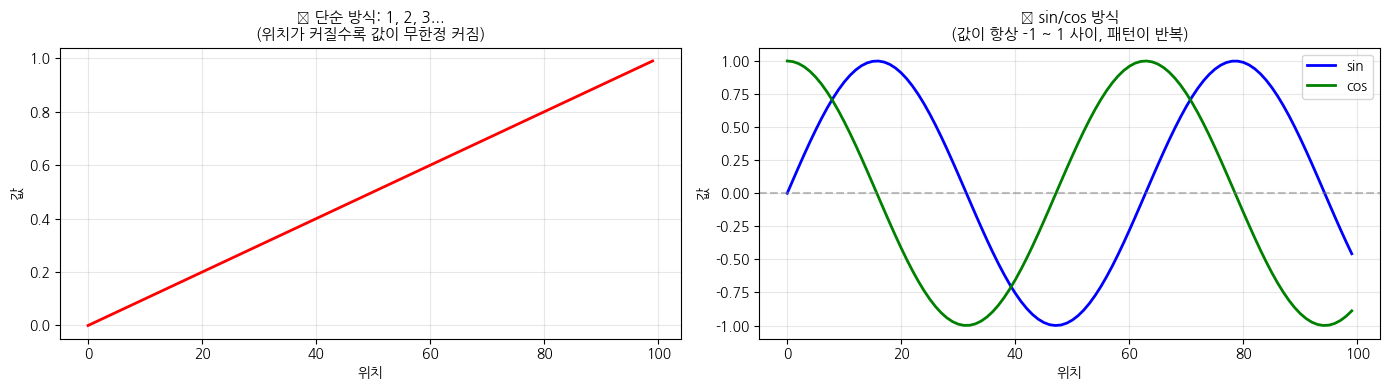

💡 sin/cos의 장점:
   1️⃣ 값이 -1 ~ 1 사이로 안정적
   2️⃣ 학습하지 않아도 됨 (고정된 패턴)
   3️⃣ 시퀀스가 길어져도 잘 작동


In [9]:
# === 직관 잡기: 왜 sin/cos을 쓸까? 단순한 예시로 살펴보기 ===

# 만약 위치 번호를 그냥 1, 2, 3, ... 으로 주면?
positions = np.arange(0, 100)
simple_pos = positions / 100  # 정규화

# sin/cos을 쓰면?
sin_wave = np.sin(positions * 0.1)
cos_wave = np.cos(positions * 0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 단순 방식
ax = axes[0]
ax.plot(positions, simple_pos, color='red', linewidth=2)
ax.set_title('❌ 단순 방식: 1, 2, 3...\n(위치가 커질수록 값이 무한정 커짐)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('위치')
ax.set_ylabel('값')
ax.grid(True, alpha=0.3)

# sin/cos 방식
ax = axes[1]
ax.plot(positions, sin_wave, label='sin', color='blue', linewidth=2)
ax.plot(positions, cos_wave, label='cos', color='green', linewidth=2)
ax.set_title('✅ sin/cos 방식\n(값이 항상 -1 ~ 1 사이, 패턴이 반복)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('위치')
ax.set_ylabel('값')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('💡 sin/cos의 장점:')
print('   1️⃣ 값이 -1 ~ 1 사이로 안정적')
print('   2️⃣ 학습하지 않아도 됨 (고정된 패턴)')
print('   3️⃣ 시퀀스가 길어져도 잘 작동')


In [10]:
# === Positional Encoding 클래스 만들기 ===

class PositionalEncoding(nn.Module):
    """
    위치 정보를 sin/cos 패턴으로 표현하는 레이어

    동작:
        1. 임베딩 벡터에 위치 정보를 '더해줌'
        2. 이렇게 더해진 결과가 Encoder/Decoder의 진짜 입력!
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # === Step 1: 빈 행렬 만들기 ===
        # (최대 길이, 차원) 크기의 0으로 채운 행렬
        pe = torch.zeros(max_len, d_model)

        # === Step 2: 위치 벡터 만들기 ===
        # [0, 1, 2, 3, ..., max_len-1]
        position = torch.arange(0, max_len).unsqueeze(1).float()

        # === Step 3: 주파수(분모) 계산 ===
        # 10000^(2i/d_model) 의 역수
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)
        )

        # === Step 4: sin과 cos 적용 ===
        pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 인덱스: sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 인덱스: cos

        # 배치 차원 추가
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        # register_buffer: 학습 안 되는 텐서로 저장
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x의 길이만큼 위치 인코딩을 더해줌
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# === 위치 인코딩 생성하기 ===
pe_layer = PositionalEncoding(d_model=512, dropout=0.0)
pe_values = pe_layer.pe[0].numpy()  # (max_len=5000, d_model=512)

print(f'📐 위치 인코딩 행렬 형태: {pe_layer.pe.shape}')
print(f'   → (배치=1, 최대 위치=5000, 차원=512)')
print(f'\n🔍 값 확인:')
print(f'   위치 0, 차원 0 (sin): {pe_values[0, 0]:.4f}  → sin(0) = 0')
print(f'   위치 0, 차원 1 (cos): {pe_values[0, 1]:.4f}  → cos(0) = 1')
print(f'   위치 1, 차원 0 (sin): {pe_values[1, 0]:.4f}  → sin(작은값) ≈ 작은값')
print(f'   위치 1, 차원 1 (cos): {pe_values[1, 1]:.4f}  → cos(작은값) ≈ 1')


📐 위치 인코딩 행렬 형태: torch.Size([1, 5000, 512])
   → (배치=1, 최대 위치=5000, 차원=512)

🔍 값 확인:
   위치 0, 차원 0 (sin): 0.0000  → sin(0) = 0
   위치 0, 차원 1 (cos): 1.0000  → cos(0) = 1
   위치 1, 차원 0 (sin): 0.8415  → sin(작은값) ≈ 작은값
   위치 1, 차원 1 (cos): 0.5403  → cos(작은값) ≈ 1


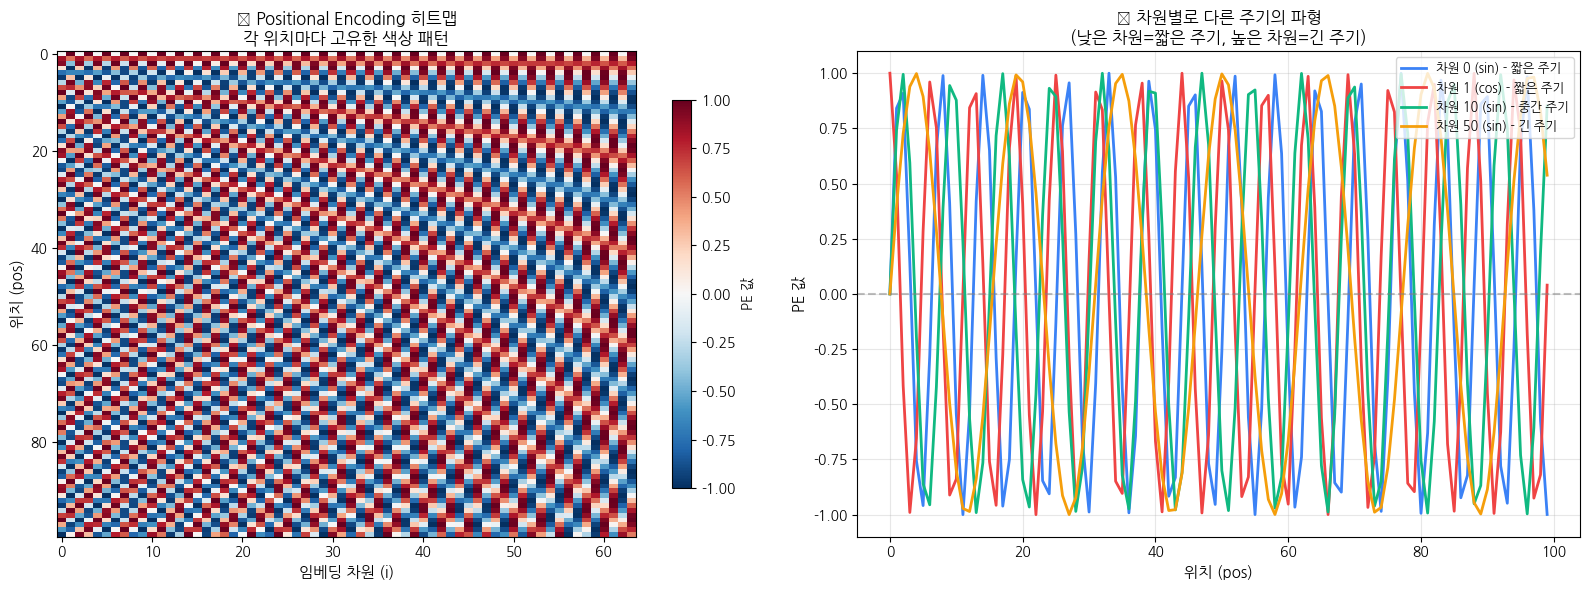

🎯 핵심 인사이트:
   • 각 위치마다 색상 패턴이 다름 → 위치를 구별 가능!
   • 차원이 높을수록 주기가 길어짐 → 다양한 거리 정보 표현
   • 사람의 지문처럼, 각 위치마다 고유한 패턴 부여


In [11]:
# === 시각화 1: Positional Encoding 전체 패턴 (히트맵) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 전체 히트맵: 100개 위치, 64개 차원
ax = axes[0]
im = ax.imshow(pe_values[:100, :64], cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel('임베딩 차원 (i)', fontsize=11)
ax.set_ylabel('위치 (pos)', fontsize=11)
ax.set_title('🌈 Positional Encoding 히트맵\n각 위치마다 고유한 색상 패턴',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='PE 값')

# (2) 차원별 주기 변화
ax = axes[1]
positions = np.arange(100)
for dim_idx, label, color in [(0, '차원 0 (sin) - 짧은 주기',  '#3B82F6'),
                               (1, '차원 1 (cos) - 짧은 주기',  '#EF4444'),
                               (10, '차원 10 (sin) - 중간 주기', '#10B981'),
                               (50, '차원 50 (sin) - 긴 주기',   '#F59E0B')]:
    ax.plot(positions, pe_values[:100, dim_idx],
            label=label, color=color, linewidth=2)

ax.set_xlabel('위치 (pos)', fontsize=11)
ax.set_ylabel('PE 값', fontsize=11)
ax.set_title('📊 차원별로 다른 주기의 파형\n(낮은 차원=짧은 주기, 높은 차원=긴 주기)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('🎯 핵심 인사이트:')
print('   • 각 위치마다 색상 패턴이 다름 → 위치를 구별 가능!')
print('   • 차원이 높을수록 주기가 길어짐 → 다양한 거리 정보 표현')
print('   • 사람의 지문처럼, 각 위치마다 고유한 패턴 부여')


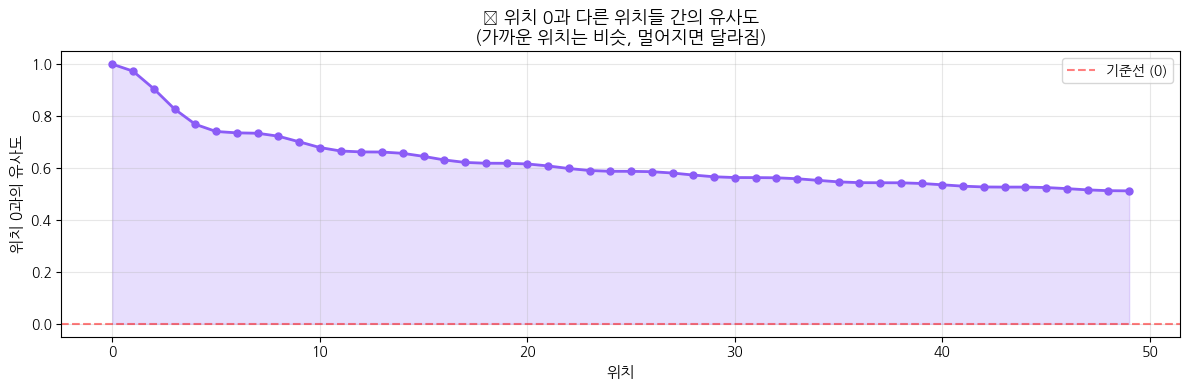

💡 패턴 해석:
   • 위치 0과 위치 0: 유사도 1.0 (완전히 같음)
   • 위치 0과 위치 1, 2, ...: 점점 감소
   • 이 패턴 덕분에 모델이 "위치가 얼마나 떨어져있는지" 학습 가능


In [12]:
# === 시각화 2: 두 위치 간의 '거리'를 시각화 ===
# 위치 0과 다른 위치들 사이의 유사도(내적)를 계산해보면 재미있는 패턴이 보입니다!

similarities = []
for pos in range(50):
    sim = np.dot(pe_values[0], pe_values[pos]) / (
        np.linalg.norm(pe_values[0]) * np.linalg.norm(pe_values[pos]))
    similarities.append(sim)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(50), similarities, marker='o', color='#8B5CF6', linewidth=2, markersize=5)
ax.fill_between(range(50), similarities, alpha=0.2, color='#8B5CF6')
ax.set_xlabel('위치', fontsize=11)
ax.set_ylabel('위치 0과의 유사도', fontsize=11)
ax.set_title('📏 위치 0과 다른 위치들 간의 유사도\n(가까운 위치는 비슷, 멀어지면 달라짐)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='기준선 (0)')
ax.legend()
plt.tight_layout()
plt.show()

print('💡 패턴 해석:')
print('   • 위치 0과 위치 0: 유사도 1.0 (완전히 같음)')
print('   • 위치 0과 위치 1, 2, ...: 점점 감소')
print('   • 이 패턴 덕분에 모델이 "위치가 얼마나 떨어져있는지" 학습 가능')


## 🔗 Token Embedding + Positional Encoding 결합

이제 두 가지를 합쳐봅시다!

```
   "나는 학교에 간다"
        ↓ Token Embedding
   [[0.2, 0.5, ...], [0.7, 0.1, ...], [0.3, 0.9, ...]]   ← 의미 정보
        ↓ + Positional Encoding
   [[0.5, 1.2, ...], [0.8, 1.5, ...], [0.6, 1.3, ...]]   ← 의미 + 위치 정보 ✨
        ↓
   Encoder로 입력!
```


In [13]:
# === 결합 실습 ===
# Section 2의 embedded를 사용 (없다면 다시 만들기)
vocab_size = 100
d_model = 512
embed = TokenEmbedding(vocab_size, d_model)
sample_tokens = torch.tensor([[10, 25, 42, 7]])
embedded = embed(sample_tokens)

# Positional Encoding 적용
pe_with_dropout = PositionalEncoding(d_model=512, dropout=0.1)
final_input = pe_with_dropout(embedded)

print(f'1️⃣ Token Embedding 결과:           {embedded.shape}')
print(f'2️⃣ + Positional Encoding 후:       {final_input.shape}')
print(f'\n🎯 이 결과가 Encoder/Decoder의 진짜 입력입니다!')
print(f'\n📌 핵심: 형태(shape)는 같아요. 하지만 값에 위치 정보가 추가됨!')

# 값 비교
print(f'\n🔍 첫 단어의 처음 5개 차원 값 비교:')
print(f'   Embedding만:        {embedded[0, 0, :5].detach().numpy().round(3)}')
print(f'   + Positional 추가:  {final_input[0, 0, :5].detach().numpy().round(3)}')
print(f'   차이가 보이죠? 위치 정보가 더해진 결과!')


1️⃣ Token Embedding 결과:           torch.Size([1, 4, 512])
2️⃣ + Positional Encoding 후:       torch.Size([1, 4, 512])

🎯 이 결과가 Encoder/Decoder의 진짜 입력입니다!

📌 핵심: 형태(shape)는 같아요. 하지만 값에 위치 정보가 추가됨!

🔍 첫 단어의 처음 5개 차원 값 비교:
   Embedding만:        [ 3.528  2.972 26.296  7.045 -6.727]
   + Positional 추가:  [ 3.921  0.     0.     8.939 -7.474]
   차이가 보이죠? 위치 정보가 더해진 결과!


## 🎯 빈칸 채우기 실습 #2

### 미션: 위치 5번 자리의 PE 값을 출력해보기


In [14]:
# === ✏️ 빈칸 채우기 실습 #2 ===
# TODO: 빈칸을 채워 위치 5번의 PE 값을 출력해보세요!

# 1) PE 객체 만들기 (차원 128)
my_pe = PositionalEncoding(d_model=128, dropout=0.0)  # 힌트: 128

# 2) 5번 위치의 PE 값 가져오기 (앞 10차원만)
position_5 = my_pe.pe[0, 5, :10]  # 힌트: 5

# 3) 출력
print(f'위치 5번의 PE 앞 10차원:')
print(position_5.numpy().round(4))

print(f'\n예상 출력: [sin값, cos값, sin값, cos값, ...] 형태')


위치 5번의 PE 앞 10차원:
[-0.9589  0.2837 -0.9277 -0.3733 -0.5711 -0.8209 -0.1051 -0.9945  0.3239
 -0.9461]

예상 출력: [sin값, cos값, sin값, cos값, ...] 형태


<details>
<summary>🔑 정답 보기</summary>

```python
my_pe = PositionalEncoding(d_model=128, dropout=0.0)
position_5 = my_pe.pe[0, 5, :10]
```
</details>

## 🧠 퀴즈 #2
1. **Positional Encoding을 더하지 않으면 어떻게 될까?**
   - "나는 너를 좋아해"와 "너는 나를 좋아해"를 구분하지 못해요! 😱

2. **왜 sin과 cos을 함께 사용할까?**
   - 두 함수의 조합으로 더 풍부한 패턴을 만들 수 있고
   - 상대적 위치 관계를 더 잘 표현할 수 있어요


---

# 4️⃣ Scaled Dot-Product Attention — Transformer의 심장 💗

## 🤔 Attention이 뭐길래?

문장 **"그 개는 너무 귀여워서 나는 그것을 안아주었다"** 를 읽어보세요.

"그것"은 무엇을 가리킬까요? → **"개"** 죠!

여러분의 뇌는 이 문장을 읽을 때 자동으로 **"그것" ↔ "개"** 의 연결을 찾았어요.
이것이 바로 **Attention**입니다!

> **Attention = "어떤 단어에 집중해야 할까?" 를 계산하는 메커니즘**

### 🔍 비유: 도서관 검색 시스템

도서관에서 책을 찾는 과정을 상상해보세요:

| 요소 | 의미 | 비유 |
|-----|------|------|
| **Q (Query)** | 내가 찾고 싶은 것 | 🔍 "Python 책 주세요" |
| **K (Key)** | 책장의 라벨/인덱스 | 📚 "프로그래밍", "요리", "역사" |
| **V (Value)** | 실제 책 내용 | 📖 책 자체 |

**과정:**
1. **Query**(내 질문)와 **Key**들(라벨)을 비교 → 어떤 책장이 관련 있나?
2. 가장 관련 있는 책장의 **Value**(내용)를 가져옴!

### 📐 수식 (한 번에 다 이해 안 돼도 괜찮아요!)

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

| 단계 | 연산 | 무엇을 하는가? |
|------|------|--------------|
| ① | `Q · K^T` | 모든 Q와 K의 유사도 계산 |
| ② | `÷ √d_k` | 값을 적당한 크기로 조정 |
| ③ | `softmax` | 확률(0~1)로 변환 |
| ④ | `× V` | 가중평균 계산 |


In [15]:
# === Attention 함수 만들기 (자세한 print 포함) ===

def scaled_dot_product_attention(Q, K, V, mask=None, verbose=True):
    """
    Scaled Dot-Product Attention

    Args:
        Q: Query  (batch, heads, seq_len, d_k)
        K: Key    (batch, heads, seq_len, d_k)
        V: Value  (batch, heads, seq_len, d_v)
        mask: 마스크 텐서 (선택)
        verbose: True면 단계별 출력
    """
    d_k = Q.size(-1)

    # === ① Q와 K의 유사도 계산 (내적) ===
    # Q·K^T: 모든 단어 쌍에 대해 "얼마나 관련있나?" 점수 계산
    scores = torch.matmul(Q, K.transpose(-2, -1))
    if verbose:
        print(f'  ① Q·K^T 점수 행렬: {scores.shape}')
        print(f'     → 각 단어와 모든 단어 사이의 유사도')

    # === ② 스케일링 (√d_k로 나눔) ===
    # 점수가 너무 커지면 softmax가 한쪽으로 쏠리는 문제 방지
    scores = scores / math.sqrt(d_k)
    if verbose:
        print(f'  ② 스케일링: ÷ √{d_k} = ÷ {math.sqrt(d_k):.2f}')

    # === 마스크 적용 (선택) ===
    # Decoder의 미래 정보 차단에 사용
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
        if verbose:
            print(f'  🎭 마스크 적용 (미래 토큰을 -∞로)')

    # === ③ Softmax로 확률 변환 ===
    # 모든 행의 합이 1이 되도록 (확률 분포)
    attn_weights = F.softmax(scores, dim=-1)
    if verbose:
        print(f'  ③ Softmax 후 행 합: {attn_weights[0,0,0].sum().item():.4f} (≈ 1.0)')
        print(f'     → 가중치 분포 (어디에 얼마나 집중할지)')

    # === ④ V에 가중치 적용 ===
    output = torch.matmul(attn_weights, V)
    if verbose:
        print(f'  ④ V에 가중치 적용: {output.shape}')
        print(f'     → 관련 있는 단어의 정보를 모아서 결합')

    return output, attn_weights


# === 실습: 4개 단어 문장으로 Attention 계산 ===
print('🚀 4개 단어로 이루어진 가상 문장에 Attention 적용\n')
batch_size = 1
n_heads = 1
seq_len = 4
d_k = 64

# 랜덤 Q, K, V (실제로는 학습된 가중치를 통해 만들어짐)
Q = torch.randn(batch_size, n_heads, seq_len, d_k)
K = torch.randn(batch_size, n_heads, seq_len, d_k)
V = torch.randn(batch_size, n_heads, seq_len, d_k)

print(f'📥 입력:')
print(f'   Q (Query): {Q.shape}  → "내가 찾는 것"')
print(f'   K (Key):   {K.shape}  → "책장 라벨"')
print(f'   V (Value): {V.shape}  → "실제 내용"')

print(f'\n--- Attention 계산 과정 ---')
output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f'\n📤 최종 출력 형태: {output.shape}')


🚀 4개 단어로 이루어진 가상 문장에 Attention 적용

📥 입력:
   Q (Query): torch.Size([1, 1, 4, 64])  → "내가 찾는 것"
   K (Key):   torch.Size([1, 1, 4, 64])  → "책장 라벨"
   V (Value): torch.Size([1, 1, 4, 64])  → "실제 내용"

--- Attention 계산 과정 ---
  ① Q·K^T 점수 행렬: torch.Size([1, 1, 4, 4])
     → 각 단어와 모든 단어 사이의 유사도
  ② 스케일링: ÷ √64 = ÷ 8.00
  ③ Softmax 후 행 합: 1.0000 (≈ 1.0)
     → 가중치 분포 (어디에 얼마나 집중할지)
  ④ V에 가중치 적용: torch.Size([1, 1, 4, 64])
     → 관련 있는 단어의 정보를 모아서 결합

📤 최종 출력 형태: torch.Size([1, 1, 4, 64])



--- 마스크 적용 Attention ---


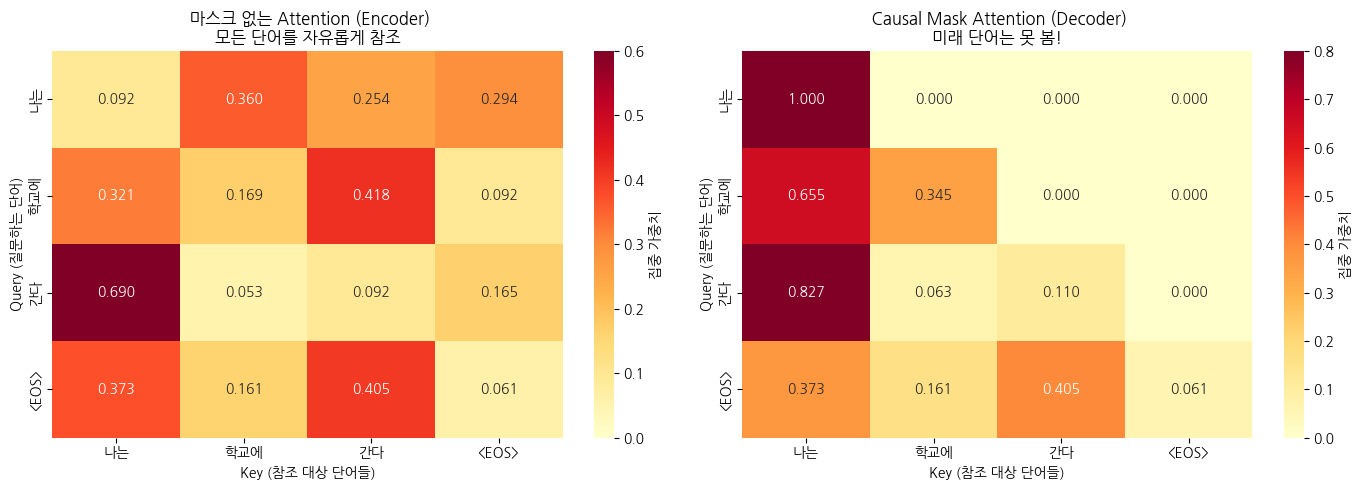


📊 어떻게 읽을까?
   • 가로(Key): 참조할 단어
   • 세로(Query): 질문하는 단어
   • 색이 진할수록 더 집중
   • 각 행의 합 = 1.0 (확률 분포)

🔍 왼쪽 vs 오른쪽:
   • 왼쪽: 모든 단어 참조 가능 (양방향) → 이해할 때 사용
   • 오른쪽: 미래 단어 못 봄 (단방향) → 생성할 때 사용


In [16]:
# === 시각화: Attention 가중치 히트맵 ===
# Attention의 핵심: '어떤 단어가 어떤 단어에 얼마나 집중하는지'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tokens = ['나는', '학교에', '간다', '<EOS>']

# (1) 마스크 없는 Attention (Encoder 스타일)
ax = axes[0]
sns.heatmap(
    attn_weights[0, 0].detach().numpy(),
    annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=tokens, yticklabels=tokens, ax=ax,
    vmin=0, vmax=0.6, cbar_kws={'label': '집중 가중치'}
)
ax.set_title(' 마스크 없는 Attention (Encoder)\n모든 단어를 자유롭게 참조',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Key (참조 대상 단어들)', fontsize=10)
ax.set_ylabel('Query (질문하는 단어)', fontsize=10)

# (2) Causal 마스크 적용 (Decoder 스타일)
causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)
print('\n--- 마스크 적용 Attention ---')
_, masked_weights = scaled_dot_product_attention(Q, K, V, mask=causal_mask, verbose=False)

ax = axes[1]
sns.heatmap(
    masked_weights[0, 0].detach().numpy(),
    annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=tokens, yticklabels=tokens, ax=ax,
    vmin=0, vmax=0.8, cbar_kws={'label': '집중 가중치'}
)
ax.set_title(' Causal Mask Attention (Decoder)\n미래 단어는 못 봄!',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Key (참조 대상 단어들)', fontsize=10)
ax.set_ylabel('Query (질문하는 단어)', fontsize=10)

plt.tight_layout()
plt.show()

print('\n📊 어떻게 읽을까?')
print('   • 가로(Key): 참조할 단어')
print('   • 세로(Query): 질문하는 단어')
print('   • 색이 진할수록 더 집중')
print('   • 각 행의 합 = 1.0 (확률 분포)')
print('\n🔍 왼쪽 vs 오른쪽:')
print('   • 왼쪽: 모든 단어 참조 가능 (양방향) → 이해할 때 사용')
print('   • 오른쪽: 미래 단어 못 봄 (단방향) → 생성할 때 사용')


## 🎨 Attention을 단계별로 시각화

Attention이 어떻게 계산되는지, 작은 예시로 **단계별로** 살펴봅시다!


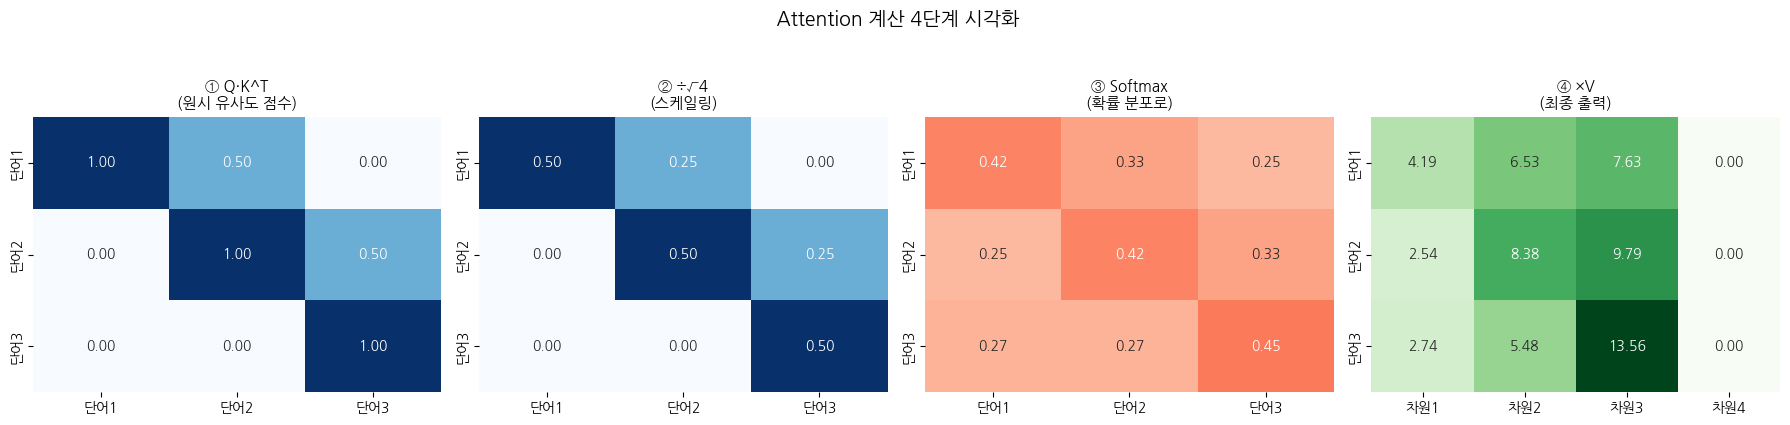

🔄 흐름 요약:
   ① Q와 K의 닮은 정도 계산
   ② 너무 큰 값을 조정
   ③ "확률"로 만들어서 한 행의 합이 1
   ④ 그 확률대로 V를 섞어서 최종 결과


In [17]:
# === 작은 예시로 Attention 단계 시각화 ===
# 3개 단어, 차원 4로 단순화 (실제는 512차원, 8헤드 등)

# 가짜 Q, K, V 만들기 (의도적으로 패턴을 보이게 설계)
small_Q = torch.tensor([[[1.0, 0.5, 0.0, 0.0],   # 단어1
                         [0.0, 1.0, 0.5, 0.0],   # 단어2
                         [0.0, 0.0, 1.0, 0.5]]]) # 단어3
small_K = torch.tensor([[[1.0, 0.0, 0.0, 0.0],
                         [0.0, 1.0, 0.0, 0.0],
                         [0.0, 0.0, 1.0, 0.0]]])
small_V = torch.tensor([[[10.0, 0.0, 0.0, 0.0],
                         [0.0, 20.0, 0.0, 0.0],
                         [0.0, 0.0, 30.0, 0.0]]])

# 단계별 계산
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
words = ['단어1', '단어2', '단어3']

# (1) Q·K^T 점수
scores = torch.matmul(small_Q, small_K.transpose(-2, -1))[0].numpy()
sns.heatmap(scores, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=words, yticklabels=words, cbar=False)
axes[0].set_title('① Q·K^T\n(원시 유사도 점수)', fontsize=11, fontweight='bold')

# (2) 스케일링
d_k = 4
scaled = scores / np.sqrt(d_k)
sns.heatmap(scaled, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=words, yticklabels=words, cbar=False)
axes[1].set_title(f'② ÷√{d_k}\n(스케일링)', fontsize=11, fontweight='bold')

# (3) Softmax
softmaxed = F.softmax(torch.tensor(scaled), dim=-1).numpy()
sns.heatmap(softmaxed, annot=True, fmt='.2f', cmap='Reds', ax=axes[2],
            xticklabels=words, yticklabels=words, cbar=False, vmin=0, vmax=1)
axes[2].set_title('③ Softmax\n(확률 분포로)', fontsize=11, fontweight='bold')

# (4) ×V → 최종 출력
output_small = np.matmul(softmaxed, small_V[0].numpy())
sns.heatmap(output_small, annot=True, fmt='.2f', cmap='Greens', ax=axes[3],
            xticklabels=['차원1', '차원2', '차원3', '차원4'],
            yticklabels=words, cbar=False)
axes[3].set_title('④ ×V\n(최종 출력)', fontsize=11, fontweight='bold')

plt.suptitle(' Attention 계산 4단계 시각화', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print('🔄 흐름 요약:')
print('   ① Q와 K의 닮은 정도 계산')
print('   ② 너무 큰 값을 조정')
print('   ③ "확률"로 만들어서 한 행의 합이 1')
print('   ④ 그 확률대로 V를 섞어서 최종 결과')


## 🎯 빈칸 채우기 실습 #3

### 미션: Attention의 가중치 합이 1이 되는지 확인하기


In [18]:
# === ✏️ 빈칸 채우기 실습 #3 ===
# Attention 가중치의 행 합이 1이 되는지 확인해봅시다!

# 1) 작은 입력 만들기 (배치=1, 헤드=1, 길이=5, 차원=8)
Q_test = torch.randn(1, 1, 5, 8)  # 힌트: 5
K_test = torch.randn(1, 1, 5, 8)
V_test = torch.randn(1, 1, 5, 8)

# 2) Attention 계산 (verbose=False로 출력 끄기)
_, weights = scaled_dot_product_attention(Q_test, K_test, V_test, verbose=False)  # 힌트: False

# 3) 각 행의 합이 1인지 확인
print('각 Query 행의 가중치 합:')
for i in range(5):
    row_sum = weights[0, 0, i].sum().item()
    print(f'  행 {i+1}: {row_sum:.4f}  {"✅" if abs(row_sum - 1.0) < 0.001 else "❌"}')


각 Query 행의 가중치 합:
  행 1: 1.0000  ✅
  행 2: 1.0000  ✅
  행 3: 1.0000  ✅
  행 4: 1.0000  ✅
  행 5: 1.0000  ✅


<details>
<summary>🔑 정답</summary>

```python
Q_test = torch.randn(1, 1, 5, 8)
_, weights = scaled_dot_product_attention(Q_test, K_test, V_test, verbose=False)
```
</details>

## 🧠 퀴즈 #3
1. **왜 `√d_k`로 나눌까?**
   - 차원이 커지면 내적값이 커지고, softmax가 한쪽으로 쏠려요 (=학습이 안 됨)
   - 적당한 크기로 조정하기 위해서!

2. **Attention 가중치의 각 행의 합은 얼마?**
   - 항상 **1**! (softmax의 특성)


---

# 5️⃣ Multi-Head Attention — 여러 관점으로 동시에 보기 👁️👁️👁️

## 🤔 왜 "여러 헤드(Multi-Head)"가 필요할까?

문장 **"고양이가 쥐를 쫓는 강아지를 보고 있다"** 를 분석해봅시다.

이 문장 안에는 여러 관계가 있어요:
- 🔍 **누가**: "고양이", "쥐", "강아지"
- ⚡ **행동**: "쫓는", "보고 있다"
- 🤝 **누가 누구를?**: "강아지가 쥐를", "고양이가 강아지를"

**하나의 Attention만 쓰면** → 한 가지 관계만 잘 잡아냅니다.
**여러 Attention(Multi-Head)을 쓰면** → 다양한 관계를 동시에 잡아냅니다!

### 🎭 비유: 8명의 전문가가 동시에 분석

```
입력 문장 → 8개의 작은 Attention(헤드)에 동시 입력
            ↓
   👨‍🏫 헤드1: "주어-동사 관계는?"
   👩‍🔬 헤드2: "수식 관계는?"
   👨‍💼 헤드3: "장소 정보는?"
   👩‍⚕️ 헤드4: "시간 정보는?"
   ... (총 8개)
            ↓
   모든 의견을 합쳐서 최종 결과!
```

### 📐 수식

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

원본 논문 설정:
- **헤드 수 (h)**: 8
- **각 헤드 차원 (d_k)**: 512 / 8 = **64**
- 8개 헤드를 합치면 → 다시 512 차원!


In [19]:
# === Multi-Head Attention 클래스 ===

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention: 여러 개의 Attention 헤드를 병렬로 실행

    동작 흐름:
        1) 입력을 Q, K, V로 변환 (선형 레이어)
        2) Q, K, V를 8개 헤드로 쪼개기
        3) 각 헤드에서 Attention 계산 (병렬!)
        4) 8개 결과를 다시 합치기
        5) 최종 선형 변환
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model은 n_heads로 나누어 떨어져야 합니다'

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # 헤드당 차원 (예: 512/8=64)

        # 4개의 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)   # Query 변환
        self.W_k = nn.Linear(d_model, d_model)   # Key 변환
        self.W_v = nn.Linear(d_model, d_model)   # Value 변환
        self.W_o = nn.Linear(d_model, d_model)   # 최종 출력 변환

        self.dropout = nn.Dropout(dropout)
        self.attn_weights = None  # 시각화용으로 저장

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # === Step 1: Q, K, V로 변환하고 헤드 분리 ===
        # 형태: (batch, seq, d_model) → (batch, heads, seq, d_k)
        Q = self.W_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # === Step 2: 각 헤드에서 Attention 계산 (병렬) ===
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        self.attn_weights = attn_weights.detach()  # 시각화용

        context = torch.matmul(attn_weights, V)

        # === Step 3: 헤드 결합 (Concat) ===
        # (batch, heads, seq, d_k) → (batch, seq, d_model)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # === Step 4: 최종 선형 변환 ===
        output = self.W_o(context)

        return output


# === 실습 ===
d_model = 512
n_heads = 8
mha = MultiHeadAttention(d_model, n_heads)

# 입력: (배치=2, 단어수=10, 차원=512)
x = torch.randn(2, 10, d_model)
output = mha(x, x, x)  # Self-Attention: Q=K=V=x

print(f'📥 입력 형태:  {x.shape}')
print(f'📤 출력 형태:  {output.shape}')
print(f'\n🎯 설정:')
print(f'   • 헤드 수:        {n_heads}개')
print(f'   • 헤드당 차원:    {d_model // n_heads}  (= 512/8)')
print(f'   • 총 차원:        {d_model}')

total_params = sum(p.numel() for p in mha.parameters())
print(f'\n📊 파라미터 수: {total_params:,}')
print(f'   • W_q: {d_model}×{d_model} = {d_model*d_model:,}')
print(f'   • W_k: {d_model}×{d_model} = {d_model*d_model:,}')
print(f'   • W_v: {d_model}×{d_model} = {d_model*d_model:,}')
print(f'   • W_o: {d_model}×{d_model} = {d_model*d_model:,}')
print(f'   • + bias 4개')


📥 입력 형태:  torch.Size([2, 10, 512])
📤 출력 형태:  torch.Size([2, 10, 512])

🎯 설정:
   • 헤드 수:        8개
   • 헤드당 차원:    64  (= 512/8)
   • 총 차원:        512

📊 파라미터 수: 1,050,624
   • W_q: 512×512 = 262,144
   • W_k: 512×512 = 262,144
   • W_v: 512×512 = 262,144
   • W_o: 512×512 = 262,144
   • + bias 4개


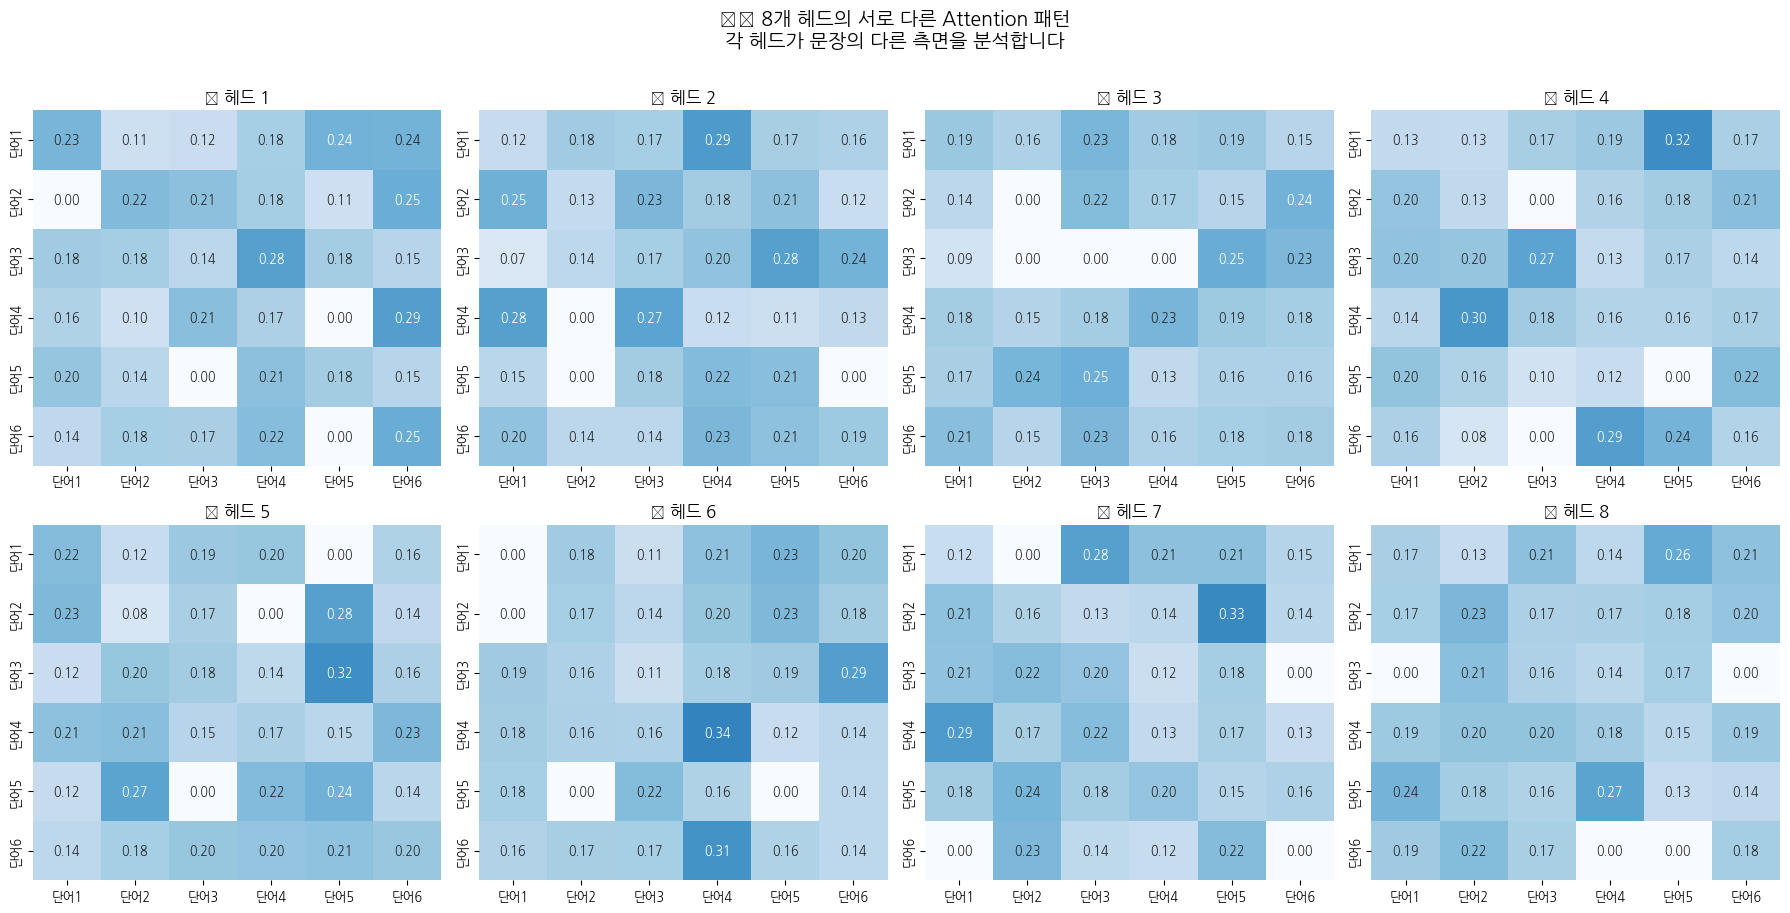

🔍 관찰 포인트:
   • 각 헤드의 색상 패턴이 다르죠?
   • 어떤 헤드는 자기 자신에 집중
   • 어떤 헤드는 다른 단어에 골고루 분산
   • 어떤 헤드는 특정 단어 쌍에 집중

💡 학습이 진행되면, 각 헤드가 의미 있는 패턴을 학습합니다!
   (예: 헤드1=문법 관계, 헤드2=의미 관계 등)


In [20]:
# === 시각화: 8개 헤드가 보는 서로 다른 패턴 ===
# 6개 단어로 이루어진 짧은 시퀀스로 테스트

short_x = torch.randn(1, 6, d_model)
_ = mha(short_x, short_x, short_x)
weights = mha.attn_weights[0].numpy()  # (n_heads=8, 6, 6)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
labels = ['단어1', '단어2', '단어3', '단어4', '단어5', '단어6']

for idx, ax in enumerate(axes.flat):
    sns.heatmap(
        weights[idx], annot=True, fmt='.2f',
        cmap='Blues', vmin=0, vmax=0.5,
        xticklabels=labels, yticklabels=labels, ax=ax,
        cbar=False, annot_kws={'size': 9}
    )
    ax.set_title(f'🎯 헤드 {idx+1}', fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=9)

plt.suptitle('👁️ 8개 헤드의 서로 다른 Attention 패턴\n각 헤드가 문장의 다른 측면을 분석합니다',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('🔍 관찰 포인트:')
print('   • 각 헤드의 색상 패턴이 다르죠?')
print('   • 어떤 헤드는 자기 자신에 집중')
print('   • 어떤 헤드는 다른 단어에 골고루 분산')
print('   • 어떤 헤드는 특정 단어 쌍에 집중')
print('\n💡 학습이 진행되면, 각 헤드가 의미 있는 패턴을 학습합니다!')
print('   (예: 헤드1=문법 관계, 헤드2=의미 관계 등)')


## 🎯 빈칸 채우기 실습 #4

### 미션: 헤드 수를 다르게 설정해보고 차원 변화 확인하기


In [21]:
# === ✏️ 빈칸 채우기 실습 #4 ===
# 헤드 수가 바뀌면 헤드당 차원이 어떻게 변할까요?

d_model = 512

# 1) 헤드 수가 4개인 MHA 만들기
mha_4 = MultiHeadAttention(d_model=d_model, n_heads=4)  # 힌트: 512

# 2) 헤드 수가 16개인 MHA 만들기
mha_16 = MultiHeadAttention(d_model=512, n_heads=16)  # 힌트: 16

# 3) 헤드당 차원 확인
print(f'헤드 4개:  헤드당 차원 = {mha_4.d_k}  (예상: 128)')
print(f'헤드 8개:  헤드당 차원 = {mha.d_k}   (예상: 64)')
print(f'헤드 16개: 헤드당 차원 = {mha_16.d_k}  (예상: 32)')

print('\n💡 헤드가 많을수록 → 헤드당 차원은 작아짐')
print('   → 더 많은 관점, 하지만 각 관점은 더 단순')


헤드 4개:  헤드당 차원 = 128  (예상: 128)
헤드 8개:  헤드당 차원 = 64   (예상: 64)
헤드 16개: 헤드당 차원 = 32  (예상: 32)

💡 헤드가 많을수록 → 헤드당 차원은 작아짐
   → 더 많은 관점, 하지만 각 관점은 더 단순


<details>
<summary>🔑 정답</summary>

```python
mha_4 = MultiHeadAttention(d_model=512, n_heads=4)
mha_16 = MultiHeadAttention(d_model=512, n_heads=16)
```
</details>

## 🧠 퀴즈 #4
1. **`d_model=512, n_heads=7`로 설정하면?**
   - 오류! 512가 7로 나누어 떨어지지 않아요. (512/7 ≈ 73.14...)

2. **헤드를 1개만 쓰면?**
   - 일반 Single-Head Attention과 같음. 다양한 관점을 잃어버려요!


---

# 6️⃣ Feed-Forward Network (FFN) & Add & Norm 🧠

## 🤔 Attention 다음에 또 뭐가 필요해?

Attention은 "어떤 단어에 집중할지" 결정해줍니다.
하지만 그 정보를 **더 깊이 처리**할 필요가 있어요!

### 💡 비유: 회의 → 정리 시간

```
1️⃣ Attention (회의)
   → 8명의 전문가가 의견 교환
   → "이 단어 중요해!", "저것도 봐!"

2️⃣ FFN (혼자만의 정리 시간) ← 지금 배울 부분
   → 각자 자리로 돌아가서 깊이 생각
   → 정보를 정제하고 추상화
```

### 📐 FFN의 구조

```
입력 (512차원)
    ↓
  W_1 (512 → 2048): 4배로 확장!
    ↓
  ReLU (음수는 0으로)
    ↓
  W_2 (2048 → 512): 다시 압축
    ↓
출력 (512차원)
```

수식:
$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

### 🤓 왜 한 번 확장했다가 다시 축소할까?

- **확장(512→2048)**: 더 많은 표현 공간에서 복잡한 패턴 학습
- **ReLU**: 비선형성 부여 (단순 선형 변환 이상)
- **축소(2048→512)**: 다시 원래 차원으로 (다음 레이어와 호환)

## 🔁 Add & Norm: 잔차 연결과 정규화

### 🤔 잔차 연결(Residual Connection)이란?

```
[입력] x ─────────────────────────┐
        ↓                          ↓ (add 더하기)
        ↓                       [+] ← 우회로!
        ↓                          ↓
   [복잡한 변환]──────────────→[출력]
   (FFN 또는 Attention)
```

이렇게 **입력을 우회해서 출력에 직접 더해주는 길**을 만들어요.

### 💡 왜? 깊은 신경망의 학습 안정성!

비유: **계단 vs 미끄럼틀**
- 변환만 있으면 → 매우 깊은 계단을 한 번에 가야 함 (어려움)
- 잔차 연결 → 중간에 미끄럼틀이 있어서 정보가 잘 전달됨!

### 🎯 LayerNorm이란?

각 단어 벡터의 값을 **평균 0, 표준편차 1**로 정규화합니다.
→ 학습이 안정적으로 진행되도록 도와줘요.


In [22]:
# === FFN과 AddNorm 클래스 ===

class PositionwiseFeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network

    'Position-wise' = 각 위치(단어)에 독립적으로 같은 변환 적용
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)    # 512 → 2048 (확장)
        self.linear2 = nn.Linear(d_ff, d_model)    # 2048 → 512 (축소)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1단계: Linear1 (확장) → ReLU → Dropout → Linear2 (축소)
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


class AddNorm(nn.Module):
    """
    Residual Connection + Layer Normalization

    LayerNorm(x + SubLayer(x))
    """
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer_output):
        # x + sublayer 결과 (잔차 연결) → LayerNorm
        return self.norm(x + self.dropout(sublayer_output))


# === 실습 ===
d_model = 512
d_ff = 2048  # FFN의 중간 차원 (4배)

ffn = PositionwiseFeedForward(d_model, d_ff)
add_norm = AddNorm(d_model)

x = torch.randn(1, 4, d_model)  # (배치=1, 단어=4, 차원=512)
ffn_out = ffn(x)
normed = add_norm(x, ffn_out)

print(f'📥 입력 형태:           {x.shape}')
print(f'🔄 FFN 통과 후:        {ffn_out.shape}')
print(f'✅ Add & Norm 후:      {normed.shape}')

print(f'\n📊 FFN 파라미터 수: {sum(p.numel() for p in ffn.parameters()):,}')
print(f'   • W1 (512→2048): {d_model*d_ff:,}')
print(f'   • W2 (2048→512): {d_ff*d_model:,}')
print(f'\n💡 FFN이 Transformer 파라미터의 약 2/3를 차지합니다!')
print(f'   → 사실 LLM의 "지식"은 대부분 FFN에 저장된다고 알려져 있어요')


📥 입력 형태:           torch.Size([1, 4, 512])
🔄 FFN 통과 후:        torch.Size([1, 4, 512])
✅ Add & Norm 후:      torch.Size([1, 4, 512])

📊 FFN 파라미터 수: 2,099,712
   • W1 (512→2048): 1,048,576
   • W2 (2048→512): 1,048,576

💡 FFN이 Transformer 파라미터의 약 2/3를 차지합니다!
   → 사실 LLM의 "지식"은 대부분 FFN에 저장된다고 알려져 있어요


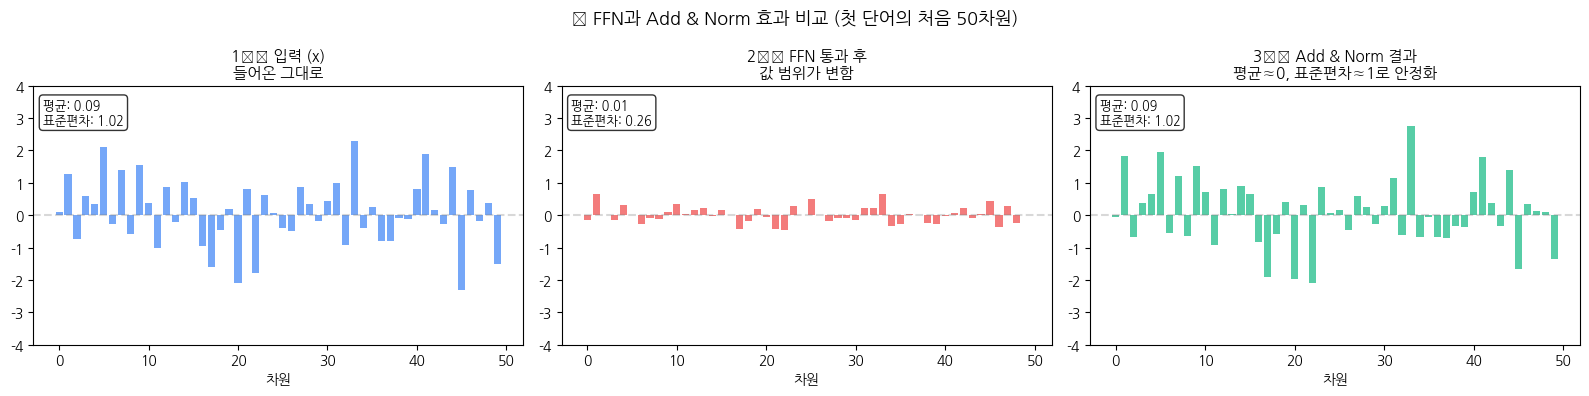

🎯 핵심:
   • FFN 출력은 값이 들쭉날쭉할 수 있어요
   • LayerNorm을 거치면 평균≈0, 표준편차≈1로 안정화!
   • 실제 측정: 평균=-0.0000, 표준편차=1.0010


In [23]:
# === 시각화: FFN과 Add&Norm 효과 ===
# 입력값, FFN 출력, 최종 정규화 후를 비교

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

data_x = x[0, 0, :50].detach().numpy()           # 첫 단어의 처음 50차원
data_ffn = ffn_out[0, 0, :50].detach().numpy()
data_norm = normed[0, 0, :50].detach().numpy()

datasets = [
    (data_x, '1️⃣ 입력 (x)', '#3B82F6', '들어온 그대로'),
    (data_ffn, '2️⃣ FFN 통과 후', '#EF4444', '값 범위가 변함'),
    (data_norm, '3️⃣ Add & Norm 결과', '#10B981', '평균≈0, 표준편차≈1로 안정화'),
]

for ax, (data, title, color, subtitle) in zip(axes, datasets):
    ax.bar(range(50), data, color=color, alpha=0.7)
    ax.set_title(f'{title}\n{subtitle}', fontsize=11, fontweight='bold')
    ax.set_xlabel('차원', fontsize=10)
    ax.set_ylim(-4, 4)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    # 평균, 표준편차 표시
    mean_val = data.mean()
    std_val = data.std()
    ax.text(0.02, 0.95, f'평균: {mean_val:.2f}\n표준편차: {std_val:.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('🔬 FFN과 Add & Norm 효과 비교 (첫 단어의 처음 50차원)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('🎯 핵심:')
print(f'   • FFN 출력은 값이 들쭉날쭉할 수 있어요')
print(f'   • LayerNorm을 거치면 평균≈0, 표준편차≈1로 안정화!')
print(f'   • 실제 측정: 평균={normed[0,0].mean().item():.4f}, 표준편차={normed[0,0].std().item():.4f}')


## 🎯 빈칸 채우기 실습 #5

### 미션: FFN의 중간 차원(d_ff)을 다르게 설정해보기


In [24]:
# === ✏️ 빈칸 채우기 실습 #5 ===
# d_ff를 작게/크게 만들어보고 파라미터 수 비교

# 1) 작은 FFN (d_ff = 1024) 만들기
small_ffn = PositionwiseFeedForward(d_model=512, d_ff=1024)  # 힌트: 1024

# 2) 큰 FFN (d_ff = 4096) 만들기
large_ffn = PositionwiseFeedForward(d_model=512, d_ff=4096)  # 힌트: 4096

# 3) 파라미터 수 비교
print(f'작은 FFN (d_ff=1024):  {sum(p.numel() for p in small_ffn.parameters()):,}')
print(f'기본 FFN (d_ff=2048):  {sum(p.numel() for p in ffn.parameters()):,}')
print(f'큰 FFN  (d_ff=4096):  {sum(p.numel() for p in large_ffn.parameters()):,}')

print(f'\n💡 d_ff가 클수록 → 표현력 ↑, 파라미터 ↑, 계산 시간 ↑')


작은 FFN (d_ff=1024):  1,050,112
기본 FFN (d_ff=2048):  2,099,712
큰 FFN  (d_ff=4096):  4,198,912

💡 d_ff가 클수록 → 표현력 ↑, 파라미터 ↑, 계산 시간 ↑


<details>
<summary>🔑 정답</summary>

```python
small_ffn = PositionwiseFeedForward(d_model=512, d_ff=1024)
large_ffn = PositionwiseFeedForward(d_model=512, d_ff=4096)
```
</details>

## 🧠 퀴즈 #5
1. **왜 ReLU가 필요할까?**
   - **비선형성**! Linear만 두 개 쌓으면 결국 하나의 Linear와 같아요.
   - ReLU 같은 비선형 함수가 있어야 복잡한 패턴 학습 가능!

2. **잔차 연결(Residual)이 없으면?**
   - 깊은 신경망에서 학습이 매우 어려움 (gradient vanishing 문제)
   - ResNet 논문이 이 기법으로 유명해졌고, Transformer도 채택!


---

# 7️⃣ Encoder — 입력을 이해하는 부분 👂

## 🎯 Encoder의 역할

비유: **외국어 통역사가 원문을 "듣고 이해"하는 과정**

```
입력: "I love AI"
        ↓ (Encoder)
이해된 의미 표현 (벡터)
        ↓ (Decoder)
출력: "나는 AI를 사랑해"
```

### 🧱 Encoder Layer 1개의 구조

지금까지 배운 부분들을 조립합니다!

```
┌─────────────────────────────┐
│        Encoder Layer        │
├─────────────────────────────┤
│  1) Multi-Head Self-Attn    │ ← 단어들 간 관계 파악
│  2) Add & Norm              │ ← 안정화
│  3) Feed-Forward Network    │ ← 정보 가공
│  4) Add & Norm              │ ← 안정화
└─────────────────────────────┘
```

**Self-Attention** = 입력 단어들끼리 Attention (자기 자신과)

### 🏢 그리고 이걸 6층으로 쌓아요!

원본 Transformer는 이 Encoder Layer를 **6개 겹쳐서** 사용합니다.
- 1층: 기본 패턴 학습
- 2층: 더 복잡한 패턴
- ...
- 6층: 매우 추상적인 의미 표현

(현대 LLM은 32층, 96층 등 훨씬 더 깊어요!)


In [25]:
# === Encoder Layer & Encoder 클래스 ===

class EncoderLayer(nn.Module):
    """
    Transformer Encoder의 한 층

    흐름: Self-Attention → Add&Norm → FFN → Add&Norm
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        # === Sub-layer 1: Self-Attention + Add&Norm ===
        attn_output = self.self_attn(x, x, x, src_mask)  # Q=K=V=x (Self!)
        x = self.norm1(x + self.dropout1(attn_output))   # 잔차 + 정규화

        # === Sub-layer 2: FFN + Add&Norm ===
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))

        return x


class Encoder(nn.Module):
    """
    Transformer Encoder: EncoderLayer를 N층 쌓음
    """
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        # nn.ModuleList: 여러 레이어를 깔끔하게 관리
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, src_mask=None):
        # 각 레이어를 순차적으로 통과
        for layer in self.layers:
            x = layer(x, src_mask)
        return self.norm(x)


# === 실습: 6층 Encoder 만들기 ===
encoder = Encoder(d_model=512, n_heads=8, d_ff=2048, n_layers=6)

# 입력: (배치=2, 단어=10, 차원=512)
x = torch.randn(2, 10, 512)
enc_output = encoder(x)

print(f'📥 Encoder 입력: {x.shape}')
print(f'📤 Encoder 출력: {enc_output.shape}')
print(f'   (형태는 같지만, 값은 의미 있는 표현으로!)')

total_params = sum(p.numel() for p in encoder.parameters())
print(f'\n📊 Encoder (6층) 총 파라미터: {total_params:,}')
print(f'   • 한 층당 약 {total_params//6:,}개')


📥 Encoder 입력: torch.Size([2, 10, 512])
📤 Encoder 출력: torch.Size([2, 10, 512])
   (형태는 같지만, 값은 의미 있는 표현으로!)

📊 Encoder (6층) 총 파라미터: 18,915,328
   • 한 층당 약 3,152,554개


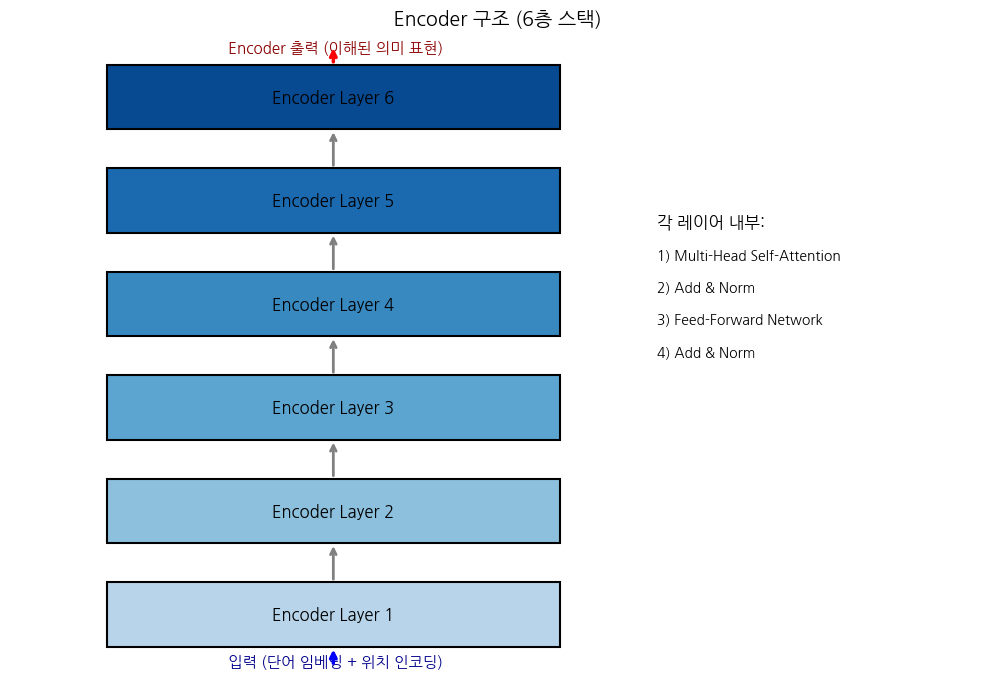

💡 깊이 쌓을수록 더 추상적이고 의미 있는 표현 학습
💡 입력과 출력의 형태는 같음 → 자유롭게 층 추가 가능!


In [26]:
# === 시각화: Encoder 구조 다이어그램 ===
fig, ax = plt.subplots(figsize=(10, 10))

# 6개 레이어 그리기
y_positions = np.linspace(0.1, 0.9, 6)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, 6))

for i, (y, color) in enumerate(zip(y_positions, colors)):
    # 레이어 박스
    ax.add_patch(plt.Rectangle((0.15, y - 0.05), 0.7, 0.1,
                                  facecolor=color, edgecolor='black', linewidth=1.5))
    ax.text(0.5, y, f'Encoder Layer {i+1}',
            ha='center', va='center', fontsize=12, fontweight='bold')

    # 화살표 (위로)
    if i < 5:
        ax.annotate('', xy=(0.5, y_positions[i+1] - 0.05),
                    xytext=(0.5, y + 0.05),
                    arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

# 입력 화살표
ax.text(0.5, 0.02, ' 입력 (단어 임베딩 + 위치 인코딩)',
        ha='center', fontsize=11, fontweight='bold', color='darkblue')
ax.annotate('', xy=(0.5, 0.05), xytext=(0.5, 0.02),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='blue'))

# 출력
ax.text(0.5, 0.97, ' Encoder 출력 (이해된 의미 표현)',
        ha='center', fontsize=11, fontweight='bold', color='darkred')
ax.annotate('', xy=(0.5, 0.98), xytext=(0.5, 0.95),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='red'))

# 한 레이어 내부 구조 (오른쪽에 별도 표시)
ax.text(1.0, 0.7, '각 레이어 내부:', fontsize=12, fontweight='bold')
ax.text(1.0, 0.65, '1) Multi-Head Self-Attention', fontsize=10)
ax.text(1.0, 0.60, '2) Add & Norm', fontsize=10)
ax.text(1.0, 0.55, '3) Feed-Forward Network', fontsize=10)
ax.text(1.0, 0.50, '4) Add & Norm', fontsize=10)

ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(' Encoder 구조 (6층 스택)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 깊이 쌓을수록 더 추상적이고 의미 있는 표현 학습')
print('💡 입력과 출력의 형태는 같음 → 자유롭게 층 추가 가능!')


---

# 8️⃣ Decoder — 출력을 생성하는 부분 🗣️

## 🎯 Decoder의 역할

비유: **통역사가 원문을 이해한 후, 번역문을 한 단어씩 말하는 과정**

```
"I love AI" (Encoder에서 이해)
        ↓
Decoder가 한 단어씩 생성:
        "나는" → "AI를" → "사랑해"
```

### 🧱 Decoder Layer 1개의 구조

Encoder보다 한 단계 더 있어요! 총 **3개의 sub-layer**:

```
┌─────────────────────────────────┐
│         Decoder Layer           │
├─────────────────────────────────┤
│  1) Masked Self-Attention       │ ← 미래 단어는 못 봄!
│  2) Add & Norm                  │
│  3) Cross-Attention             │ ← Encoder와 연결!
│  4) Add & Norm                  │
│  5) Feed-Forward Network        │
│  6) Add & Norm                  │
└─────────────────────────────────┘
```

### 🎭 두 가지 새로운 개념

#### 1️⃣ Masked Self-Attention
- 단어를 **하나씩 순차적으로** 생성하기 때문에
- 아직 만들지 않은 미래 단어를 미리 보면 **반칙**!
- 그래서 **마스크**로 가려서 못 보게 함

#### 2️⃣ Cross-Attention
- Encoder의 출력(원문 이해 결과)을 참조
- Q = Decoder (지금 무엇을 말할까?)
- K, V = Encoder (원문에 무슨 정보가 있나?)

### 🃏 Causal Mask 시각화

```
Q\K  단어1  단어2  단어3  단어4
단어1  ✅    ❌    ❌    ❌
단어2  ✅    ✅    ❌    ❌
단어3  ✅    ✅    ✅    ❌
단어4  ✅    ✅    ✅    ✅
```

각 단어는 자기 자신과 **이전** 단어들만 볼 수 있어요!


In [27]:
# === Decoder Layer & Decoder 클래스 ===

class DecoderLayer(nn.Module):
    """
    Transformer Decoder의 한 층

    흐름:
        1) Masked Self-Attention → Add&Norm
        2) Cross-Attention (Encoder 참조) → Add&Norm
        3) FFN → Add&Norm
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)   # Masked
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)  # Cross
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_output, tgt_mask=None, src_mask=None):
        # === Sub-layer 1: Masked Self-Attention ===
        # 자기 자신만 Q=K=V로 사용, but 미래는 마스크!
        attn1 = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout1(attn1))

        # === Sub-layer 2: Cross-Attention ===
        # Q = Decoder, K=V = Encoder 출력
        # → "원문의 어디를 참조할까?"
        attn2 = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout2(attn2))

        # === Sub-layer 3: FFN ===
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))

        return x


class Decoder(nn.Module):
    """Transformer Decoder: DecoderLayer를 N층 쌓음"""
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, enc_output, tgt_mask=None, src_mask=None):
        for layer in self.layers:
            x = layer(x, enc_output, tgt_mask, src_mask)
        return self.norm(x)


# === 실습 ===
decoder = Decoder(d_model=512, n_heads=8, d_ff=2048, n_layers=6)

# Causal 마스크 생성 (하삼각 행렬)
tgt_len = 8
tgt_mask = torch.tril(torch.ones(tgt_len, tgt_len)).unsqueeze(0).unsqueeze(0)

tgt = torch.randn(2, tgt_len, 512)  # Decoder 입력 (이전 단어들)
dec_output = decoder(tgt, enc_output, tgt_mask=tgt_mask)

print(f'📥 Decoder 입력:    {tgt.shape}  (지금까지 만든 단어들)')
print(f'📥 Encoder 출력:    {enc_output.shape}  (원문 정보)')
print(f'🃏 Causal 마스크:   {tgt_mask.shape}  (미래 차단)')
print(f'📤 Decoder 출력:    {dec_output.shape}')
print(f'\n📊 Decoder 총 파라미터: {sum(p.numel() for p in decoder.parameters()):,}')


📥 Decoder 입력:    torch.Size([2, 8, 512])  (지금까지 만든 단어들)
📥 Encoder 출력:    torch.Size([2, 10, 512])  (원문 정보)
🃏 Causal 마스크:   torch.Size([1, 1, 8, 8])  (미래 차단)
📤 Decoder 출력:    torch.Size([2, 8, 512])

📊 Decoder 총 파라미터: 25,225,216


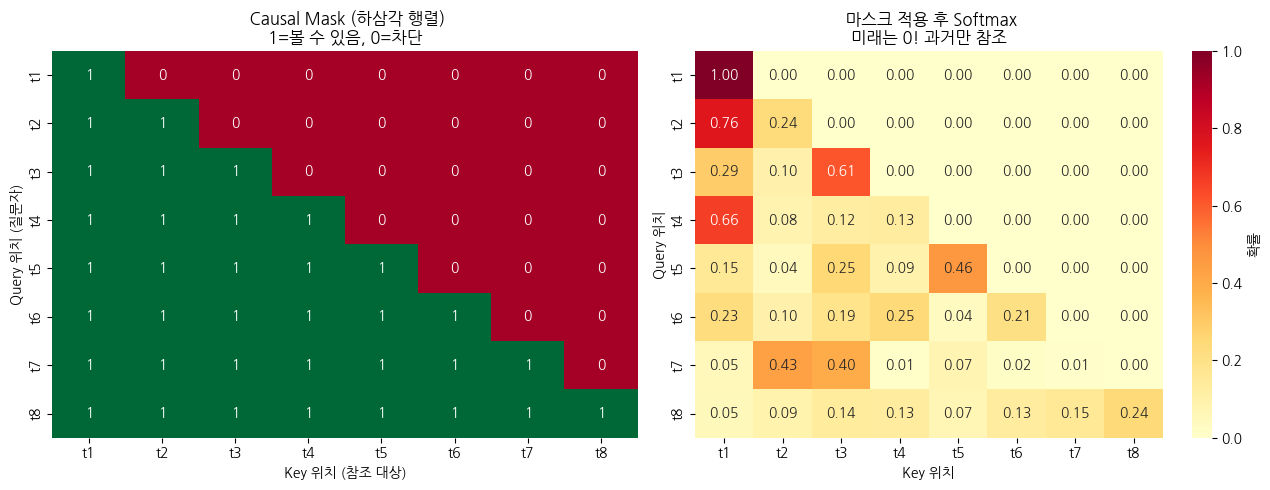

💡 마스크의 역할:
   • 단어를 하나씩 생성할 때 미래 정보 누설 방지
   • t1을 만들 때는 t1만, t2를 만들 때는 t1, t2만 볼 수 있음
   • 이를 "Autoregressive (자기회귀)" 생성이라고 함

🤔 만약 마스크가 없다면?
   → 학습할 때 정답을 미리 컨닝하는 셈 (실제 사용 시 작동 안 함)


In [28]:
# === 시각화: Causal Mask가 어떻게 작동하는지 보기 ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (1) 마스크 패턴
ax = axes[0]
mask_vis = tgt_mask[0, 0].numpy()
sns.heatmap(mask_vis, annot=True, fmt='.0f',
            cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=[f't{i+1}' for i in range(tgt_len)],
            yticklabels=[f't{i+1}' for i in range(tgt_len)],
            ax=ax, cbar=False)
ax.set_title(' Causal Mask (하삼각 행렬)\n1=볼 수 있음, 0=차단',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Key 위치 (참조 대상)', fontsize=10)
ax.set_ylabel('Query 위치 (질문자)', fontsize=10)

# (2) 마스크 적용 후 softmax 결과
ax = axes[1]
scores_before = torch.randn(tgt_len, tgt_len)
scores_after = scores_before.clone()
scores_after[tgt_mask[0, 0] == 0] = float('-inf')
probs = F.softmax(scores_after, dim=-1).numpy()
sns.heatmap(probs, annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=[f't{i+1}' for i in range(tgt_len)],
            yticklabels=[f't{i+1}' for i in range(tgt_len)],
            ax=ax, cbar=True, cbar_kws={'label': '확률'})
ax.set_title(' 마스크 적용 후 Softmax\n미래는 0! 과거만 참조',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Key 위치', fontsize=10)
ax.set_ylabel('Query 위치', fontsize=10)

plt.tight_layout()
plt.show()

print('💡 마스크의 역할:')
print('   • 단어를 하나씩 생성할 때 미래 정보 누설 방지')
print('   • t1을 만들 때는 t1만, t2를 만들 때는 t1, t2만 볼 수 있음')
print('   • 이를 "Autoregressive (자기회귀)" 생성이라고 함')
print('\n🤔 만약 마스크가 없다면?')
print('   → 학습할 때 정답을 미리 컨닝하는 셈 (실제 사용 시 작동 안 함)')


## 🎯 빈칸 채우기 실습 #6

### 미션: 다양한 크기의 Causal Mask 만들기


In [29]:
# === ✏️ 빈칸 채우기 실습 #6 ===
# 다양한 길이의 Causal Mask를 만들어봅시다!

# 1) 길이 5짜리 Causal Mask 만들기
mask_5 = torch.tril(torch.ones(5, 5))  # 힌트: 5

# 2) 길이 10짜리 Causal Mask 만들기
mask_10 = torch.tril(torch.ones(10, 10))  # 힌트: 10

# 3) 출력해서 패턴 확인
print('Causal Mask (5×5):')
print(mask_5.numpy().astype(int))
print('\n💡 1로 채워진 부분만 참조 가능!')

print(f'\nMask (5×5) 합계: {mask_5.sum().item()}  (예상: 15 = 1+2+3+4+5)')
print(f'Mask (10×10) 합계: {mask_10.sum().item()}  (예상: 55 = 1+2+...+10)')


Causal Mask (5×5):
[[1 0 0 0 0]
 [1 1 0 0 0]
 [1 1 1 0 0]
 [1 1 1 1 0]
 [1 1 1 1 1]]

💡 1로 채워진 부분만 참조 가능!

Mask (5×5) 합계: 15.0  (예상: 15 = 1+2+3+4+5)
Mask (10×10) 합계: 55.0  (예상: 55 = 1+2+...+10)


<details>
<summary>🔑 정답</summary>

```python
mask_5 = torch.tril(torch.ones(5, 5))
mask_10 = torch.tril(torch.ones(10, 10))
```
</details>

## 🧠 퀴즈 #6
1. **Encoder와 Decoder의 차이는?**
   - Encoder: 입력 전체를 한 번에 처리 (양방향)
   - Decoder: 한 단어씩 순차 생성 (단방향, 마스크 사용)

2. **Cross-Attention은 누구와 누구를 연결?**
   - Q = Decoder (지금 생성 중인 단어)
   - K, V = Encoder 출력 (원문 정보)


---

# 9️⃣ 🎉 전체 Transformer 조립!

## 🏗️ 모든 부품을 조립해봅시다

지금까지 만든 부품들:
- ✅ Token Embedding
- ✅ Positional Encoding
- ✅ Multi-Head Attention
- ✅ Feed-Forward Network
- ✅ Add & Norm
- ✅ Encoder (6층)
- ✅ Decoder (6층)

이제 전체 Transformer를 만들 차례!

### 🎯 전체 흐름

```
"I love AI"
    ↓
[Token Embedding (src)]  →  단어를 벡터로
    ↓
[Positional Encoding]    →  위치 정보 추가
    ↓
[Encoder × 6]           →  의미 추출 (양방향)
    ↓
    └─────────────┐
                  ↓
[Decoder × 6]    ←  Cross-Attention으로 연결
    ↑                  ↓
[Positional Encoding]
    ↑
[Token Embedding (tgt)]
    ↑
"<SOS>"  (시작 신호)

    ↓ (Decoder 출력)

[Linear (차원 → 어휘 크기)]  →  vocabulary 크기로 변환
    ↓
[Softmax]                    →  각 단어의 확률
    ↓
"나는 AI를 사랑해 <EOS>"
```


In [30]:
# === 전체 Transformer 클래스 ===

class Transformer(nn.Module):
    """
    완전한 Transformer 모델 (Sequence-to-Sequence)

    구성: 임베딩 → 위치인코딩 → Encoder → Decoder → Linear → 출력
    """
    def __init__(self, src_vocab, tgt_vocab, d_model=512, n_heads=8,
                 d_ff=2048, n_layers=6, dropout=0.1, max_len=5000):
        super().__init__()

        # === 임베딩 ===
        self.src_embed = TokenEmbedding(src_vocab, d_model)
        self.tgt_embed = TokenEmbedding(tgt_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # === Encoder & Decoder ===
        self.encoder = Encoder(d_model, n_heads, d_ff, n_layers, dropout)
        self.decoder = Decoder(d_model, n_heads, d_ff, n_layers, dropout)

        # === 출력 레이어 (d_model → target vocabulary 크기) ===
        self.output_linear = nn.Linear(d_model, tgt_vocab)

        # 파라미터 초기화 (Xavier uniform)
        self._init_parameters()

    def _init_parameters(self):
        """가중치를 잘 초기화 (학습 안정성 향상)"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_causal_mask(self, size):
        """Decoder용 하삼각 마스크 생성"""
        mask = torch.tril(torch.ones(size, size)).unsqueeze(0).unsqueeze(0)
        return mask  # (1, 1, size, size)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # === 1) 임베딩 + 위치 인코딩 ===
        src_emb = self.pos_enc(self.src_embed(src))
        tgt_emb = self.pos_enc(self.tgt_embed(tgt))

        # === 2) Decoder Causal Mask 자동 생성 ===
        if tgt_mask is None:
            tgt_mask = self.make_causal_mask(tgt.size(1)).to(tgt.device)

        # === 3) Encoder 통과 ===
        enc_output = self.encoder(src_emb, src_mask)

        # === 4) Decoder 통과 (Encoder 결과 참조) ===
        dec_output = self.decoder(tgt_emb, enc_output, tgt_mask, src_mask)

        # === 5) 최종 선형 변환 (각 단어의 점수) ===
        logits = self.output_linear(dec_output)

        return logits


# === 실습: 전체 Transformer 만들기 (원본 논문 설정) ===
SRC_VOCAB = 1000   # 소스(영어) 어휘 크기
TGT_VOCAB = 1200   # 타겟(한국어) 어휘 크기

model = Transformer(
    src_vocab=SRC_VOCAB,
    tgt_vocab=TGT_VOCAB,
    d_model=512,      # 임베딩 차원
    n_heads=8,        # 헤드 수
    d_ff=2048,        # FFN 중간 차원
    n_layers=6,       # Encoder/Decoder 층수
    dropout=0.1
)

# Forward pass 테스트
src = torch.randint(0, SRC_VOCAB, (2, 10))   # (배치=2, 소스길이=10)
tgt = torch.randint(0, TGT_VOCAB, (2, 8))    # (배치=2, 타겟길이=8)

logits = model(src, tgt)

print('='*60)
print('       🏗️  Transformer 모델 구성 완료!')
print('='*60)
print(f'📥 소스 입력:    {src.shape}     (배치, 소스 길이)')
print(f'📥 타겟 입력:    {tgt.shape}     (배치, 타겟 길이)')
print(f'📤 출력 logits:  {logits.shape}  (배치, 타겟 길이, 어휘 크기)')
print(f'\n🎯 logits 해석:')
print(f'   각 위치마다 {TGT_VOCAB}개 단어의 점수')
print(f'   가장 높은 점수의 단어가 예측 결과!')

total = sum(p.numel() for p in model.parameters())
print(f'\n📊 총 파라미터: {total:,} ({total/1e6:.1f}M)')


       🏗️  Transformer 모델 구성 완료!
📥 소스 입력:    torch.Size([2, 10])     (배치, 소스 길이)
📥 타겟 입력:    torch.Size([2, 8])     (배치, 타겟 길이)
📤 출력 logits:  torch.Size([2, 8, 1200])  (배치, 타겟 길이, 어휘 크기)

🎯 logits 해석:
   각 위치마다 1200개 단어의 점수
   가장 높은 점수의 단어가 예측 결과!

📊 총 파라미터: 45,882,544 (45.9M)


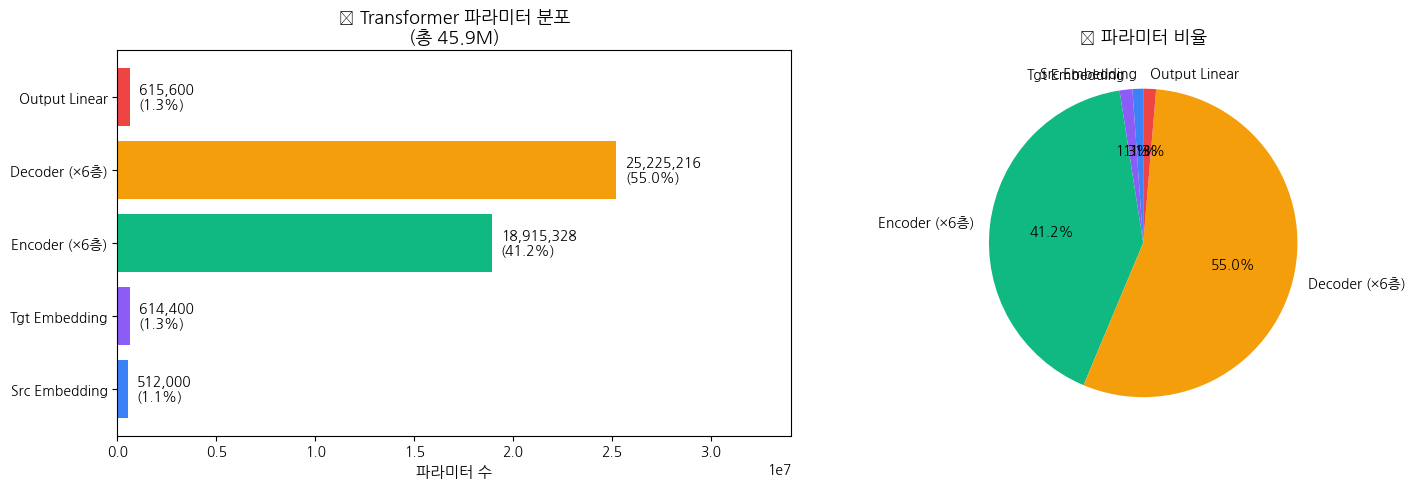

🎯 인사이트:
   • Encoder와 Decoder가 대부분의 파라미터를 차지
   • Decoder가 Encoder보다 약간 더 큰 이유: Cross-Attention 추가
   • 출력 Linear도 의외로 큰 비중 (vocab 크기에 비례)


In [31]:
# === 시각화: 모델 파라미터가 어디에 얼마나 있는지 ===
components = {
    'Src Embedding':  sum(p.numel() for p in model.src_embed.parameters()),
    'Tgt Embedding':  sum(p.numel() for p in model.tgt_embed.parameters()),
    'Encoder (×6층)': sum(p.numel() for p in model.encoder.parameters()),
    'Decoder (×6층)': sum(p.numel() for p in model.decoder.parameters()),
    'Output Linear':  sum(p.numel() for p in model.output_linear.parameters()),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) 막대그래프
ax = axes[0]
colors = ['#3B82F6', '#8B5CF6', '#10B981', '#F59E0B', '#EF4444']
bars = ax.barh(list(components.keys()), list(components.values()), color=colors)

for bar, val in zip(bars, components.values()):
    ax.text(bar.get_width() + total*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}\n({val/total*100:.1f}%)', va='center', fontsize=10)

ax.set_xlabel('파라미터 수', fontsize=11)
ax.set_title(f'📊 Transformer 파라미터 분포\n(총 {total/1e6:.1f}M)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max(components.values()) * 1.35)

# (2) 파이 차트
ax = axes[1]
ax.pie(components.values(), labels=components.keys(), colors=colors,
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
ax.set_title('🥧 파라미터 비율', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('🎯 인사이트:')
print('   • Encoder와 Decoder가 대부분의 파라미터를 차지')
print('   • Decoder가 Encoder보다 약간 더 큰 이유: Cross-Attention 추가')
print('   • 출력 Linear도 의외로 큰 비중 (vocab 크기에 비례)')


## 🎯 빈칸 채우기 실습 #7

### 미션: 작은 Transformer 만들고 차원 변화 추적하기


In [32]:
# === ✏️ 빈칸 채우기 실습 #7 ===
# 더 작은 Transformer를 만들어 실행해봅시다.

# 1) 작은 Transformer 만들기
small_transformer = Transformer(
    src_vocab=100,
    tgt_vocab=100,
    d_model=64,      # 힌트: 64
    n_heads=4,      # 힌트: 4
    d_ff=256,         # 힌트: 256
    n_layers=2,     # 힌트: 2
    dropout=0.1
)

# 2) 입력 만들기
src_input = torch.randint(0, 100, (1, 5))  # (배치=1, 길이=5)
tgt_input = torch.randint(0, 100, (1, 4))  # (배치=1, 길이=4)

# 3) 실행
output = small_transformer(src_input, tgt_input)

print(f'소스 입력 형태:   {src_input.shape}')
print(f'타겟 입력 형태:   {tgt_input.shape}')
print(f'출력 형태:        {output.shape}')
print(f'\n예상 출력 형태: (1, 4, 100)')

# 4) 파라미터 수 비교
small_params = sum(p.numel() for p in small_transformer.parameters())
print(f'\n작은 모델 파라미터: {small_params:,} ({small_params/1e6:.2f}M)')
print(f'기본 모델 파라미터: {total:,} ({total/1e6:.2f}M)')
print(f'크기 차이: {total / small_params:.1f}배')


소스 입력 형태:   torch.Size([1, 5])
타겟 입력 형태:   torch.Size([1, 4])
출력 형태:        torch.Size([1, 4, 100])

예상 출력 형태: (1, 4, 100)

작은 모델 파라미터: 253,028 (0.25M)
기본 모델 파라미터: 45,882,544 (45.88M)
크기 차이: 181.3배


<details>
<summary>🔑 정답</summary>

```python
small_transformer = Transformer(
    src_vocab=100, tgt_vocab=100,
    d_model=64, n_heads=4, d_ff=256, n_layers=2
)
```
</details>

## 🎓 중간 점검: 지금까지의 여정

```
✅ Token Embedding        - 단어를 벡터로
✅ Positional Encoding    - 위치 정보 추가
✅ Multi-Head Attention   - 여러 관점에서 분석
✅ FFN & Add&Norm         - 정보 처리와 안정화
✅ Encoder                - 입력 이해
✅ Decoder                - 출력 생성
✅ Transformer            - 전체 조립 완성!
```

이제 마지막 단계입니다: **실제로 학습시켜보기**!


---

# 🔟 번역 실습 — 직접 학습시켜보기 🎓

## 🎯 이번에 해볼 것

작은 한국어 → 영어 번역기를 **실제로 학습**시켜봅시다!

```
"나는 학생 이다" → 학습 → "I am a student"
```

### 📚 학습 과정 미리보기

```
1) 데이터 준비    : 8개의 (한국어, 영어) 쌍
2) 작은 모델 생성  : d_model=64로 가볍게
3) 학습 루프 실행  : 200번 반복
4) 학습 곡선 확인  : Loss가 줄어드는 모습
5) 번역 테스트   : 학습된 모델로 번역!
```

### 💡 특수 토큰이란?

번역할 때 필요한 약속된 신호들:

| 토큰 | 의미 | 예시 |
|------|------|------|
| `<PAD>` (0) | 빈 자리 채우기 | "I am" + PAD + PAD (길이 맞춤) |
| `<SOS>` (1) | 시작 신호 | "**\<SOS\>** I am a student" |
| `<EOS>` (2) | 끝 신호 | "I am a student **\<EOS\>**" |


In [33]:
# === 1단계: 데이터 준비 ===

# 특수 토큰 번호
PAD, SOS, EOS = 0, 1, 2

# 소스(한국어) 어휘 사전
src_vocab = {
    '<PAD>': 0, '<SOS>': 1, '<EOS>': 2,
    '나는': 3, '너는': 4, '그는': 5, '그녀는': 6,
    '학생': 7, '선생님': 8, '개발자': 9, '의사': 10,
    '이다': 11, '좋다': 12, '크다': 13,
    '매우': 14, '아주': 15
}

# 타겟(영어) 어휘 사전
tgt_vocab = {
    '<PAD>': 0, '<SOS>': 1, '<EOS>': 2,
    'I': 3, 'you': 4, 'he': 5, 'she': 6,
    'am': 7, 'are': 8, 'is': 9,
    'a': 10, 'very': 11, 'really': 12,
    'student': 13, 'teacher': 14, 'developer': 15, 'doctor': 16,
    'good': 17, 'big': 18
}

# 역사전 (번호 → 단어)
src_idx2word = {v: k for k, v in src_vocab.items()}
tgt_idx2word = {v: k for k, v in tgt_vocab.items()}

# 학습 데이터: (한국어 토큰, 영어 토큰) 쌍
train_pairs = [
    ([3, 7, 11, 2],   [1, 3, 7, 10, 13, 2]),   # 나는 학생 이다     → I am a student
    ([4, 8, 11, 2],   [1, 4, 8, 10, 14, 2]),   # 너는 선생님 이다   → you are a teacher
    ([5, 9, 11, 2],   [1, 5, 9, 10, 15, 2]),   # 그는 개발자 이다   → he is a developer
    ([6, 10, 11, 2],  [1, 6, 9, 10, 16, 2]),   # 그녀는 의사 이다   → she is a doctor
    ([3, 14, 12, 2],  [1, 3, 7, 11, 17, 2]),   # 나는 매우 좋다     → I am very good
    ([5, 15, 13, 2],  [1, 5, 9, 12, 18, 2]),   # 그는 아주 크다     → he is really big
    ([4, 14, 12, 2],  [1, 4, 8, 11, 17, 2]),   # 너는 매우 좋다     → you are very good
    ([6, 14, 13, 2],  [1, 6, 9, 11, 18, 2]),   # 그녀는 매우 크다   → she is very big
]

def pad_sequence(seq, max_len):
    """짧은 시퀀스에 PAD를 채워서 같은 길이로 만들기"""
    return seq + [PAD] * (max_len - len(seq))

# 최대 길이에 맞춰 패딩
src_max = max(len(s) for s, _ in train_pairs)
tgt_max = max(len(t) for _, t in train_pairs)

src_tensor = torch.tensor([pad_sequence(s, src_max) for s, _ in train_pairs])
tgt_tensor = torch.tensor([pad_sequence(t, tgt_max) for _, t in train_pairs])

print(f'📚 어휘 사전:')
print(f'   소스 (한국어): {len(src_vocab)}개 단어')
print(f'   타겟 (영어):   {len(tgt_vocab)}개 단어')
print(f'\n📊 학습 데이터: {len(train_pairs)} 쌍')
print(f'   소스 텐서: {src_tensor.shape}')
print(f'   타겟 텐서: {tgt_tensor.shape}')

print(f'\n📝 예시 1:')
print(f'   한국어: {[src_idx2word[i.item()] for i in src_tensor[0]]}')
print(f'   영어:   {[tgt_idx2word[i.item()] for i in tgt_tensor[0]]}')
print(f'\n📝 예시 2:')
print(f'   한국어: {[src_idx2word[i.item()] for i in src_tensor[3]]}')
print(f'   영어:   {[tgt_idx2word[i.item()] for i in tgt_tensor[3]]}')


📚 어휘 사전:
   소스 (한국어): 16개 단어
   타겟 (영어):   19개 단어

📊 학습 데이터: 8 쌍
   소스 텐서: torch.Size([8, 4])
   타겟 텐서: torch.Size([8, 6])

📝 예시 1:
   한국어: ['나는', '학생', '이다', '<EOS>']
   영어:   ['<SOS>', 'I', 'am', 'a', 'student', '<EOS>']

📝 예시 2:
   한국어: ['그녀는', '의사', '이다', '<EOS>']
   영어:   ['<SOS>', 'she', 'is', 'a', 'doctor', '<EOS>']


## 🎓 학습이 어떻게 진행될까?

### Teacher Forcing 기법

학습할 때는 **정답을 보여주면서** 가르칩니다. 마치 선생님이 옆에서 도와주듯이!

```
입력 (Decoder 입력):  <SOS>   I    am    a    student
                       ↓     ↓    ↓    ↓     ↓
모델이 예측해야 할 것:  I     am   a    student <EOS>
                  (각 위치에서 다음 단어 예측!)
```

### 손실 함수 (Loss Function)

- **Cross-Entropy Loss**: 예측이 정답과 얼마나 다른지 측정
- 값이 작을수록 좋음 (0에 가까워질수록 잘 학습됨)


In [34]:
# === 2단계: 작은 Transformer 만들기 ===
# 데이터가 적으니까 모델도 작게!

small_model = Transformer(
    src_vocab=len(src_vocab),   # 16
    tgt_vocab=len(tgt_vocab),   # 19
    d_model=64,                 # 작은 차원
    n_heads=4,                  # 작은 헤드 수
    d_ff=128,                   # 작은 FFN
    n_layers=2,                 # 2층만!
    dropout=0.1
).to(device)

# Cross-Entropy Loss (PAD는 무시)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

# Adam 옵티마이저
optimizer = optim.Adam(
    small_model.parameters(),
    lr=0.001,
    betas=(0.9, 0.98),
    eps=1e-9
)

# 데이터를 GPU/CPU로 이동
src_data = src_tensor.to(device)
tgt_data = tgt_tensor.to(device)

print(f'🤖 작은 모델 정보:')
print(f'   d_model:  64')
print(f'   n_heads:  4')
print(f'   n_layers: 2')
print(f'   파라미터: {sum(p.numel() for p in small_model.parameters()):,}')
print(f'   디바이스: {device}')


🤖 작은 모델 정보:
   d_model:  64
   n_heads:  4
   n_layers: 2
   파라미터: 171,155
   디바이스: cuda


In [35]:
# === 3단계: 학습 루프 실행 ===

losses = []
n_epochs = 200

small_model.train()  # 학습 모드

print('🚀 학습 시작!\n')

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Teacher Forcing
    # 입력:  <SOS> I am a student         (마지막 EOS 제외)
    # 정답:  I am a student <EOS>          (첫 SOS 제외)
    tgt_input = tgt_data[:, :-1]
    tgt_label = tgt_data[:, 1:]

    # Forward
    logits = small_model(src_data, tgt_input)

    # Loss 계산 (batch * seq 형태로 펼치기)
    loss = criterion(
        logits.reshape(-1, len(tgt_vocab)),
        tgt_label.reshape(-1)
    )

    # Backward & 가중치 업데이트
    loss.backward()
    torch.nn.utils.clip_grad_norm_(small_model.parameters(), 1.0)  # 폭주 방지
    optimizer.step()

    losses.append(loss.item())

    # 40 epoch마다 출력
    if (epoch + 1) % 40 == 0:
        print(f'   Epoch [{epoch+1:3d}/{n_epochs}]  Loss: {loss.item():.4f}')

print(f'\n✅ 학습 완료!')
print(f'   초기 Loss: {losses[0]:.4f}')
print(f'   최종 Loss: {losses[-1]:.4f}')
print(f'   감소 비율: {(1 - losses[-1]/losses[0])*100:.1f}%')


🚀 학습 시작!

   Epoch [ 40/200]  Loss: 0.2116
   Epoch [ 80/200]  Loss: 0.0399
   Epoch [120/200]  Loss: 0.0181
   Epoch [160/200]  Loss: 0.0078
   Epoch [200/200]  Loss: 0.0071

✅ 학습 완료!
   초기 Loss: 3.8116
   최종 Loss: 0.0071
   감소 비율: 99.8%


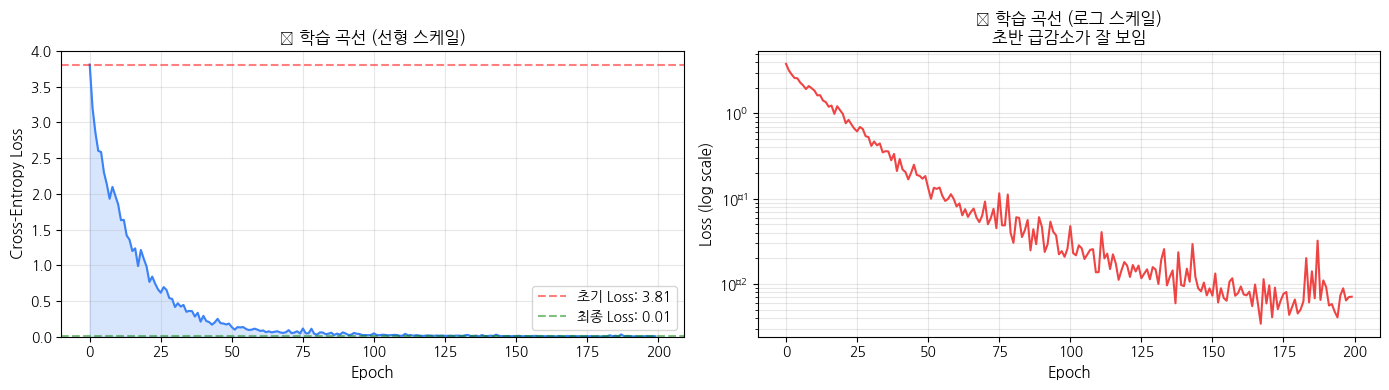

💡 그래프 해석:
   • 초반: Loss가 급격히 감소 (큰 패턴부터 학습)
   • 중반: 천천히 감소 (세밀한 부분 학습)
   • 후반: 거의 0에 수렴 (학습 완료!)


In [36]:
# === 시각화: 학습 곡선 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (1) 전체 학습 곡선
ax = axes[0]
ax.plot(losses, color='#3B82F6', linewidth=1.5)
ax.fill_between(range(len(losses)), losses, alpha=0.2, color='#3B82F6')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax.set_title('📉 학습 곡선 (선형 스케일)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# 주요 포인트 표시
ax.axhline(y=losses[0], color='red', linestyle='--', alpha=0.5, label=f'초기 Loss: {losses[0]:.2f}')
ax.axhline(y=losses[-1], color='green', linestyle='--', alpha=0.5, label=f'최종 Loss: {losses[-1]:.2f}')
ax.legend(fontsize=10)

# (2) 로그 스케일
ax = axes[1]
ax.semilogy(losses, color='#EF4444', linewidth=1.5)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (log scale)', fontsize=11)
ax.set_title('📉 학습 곡선 (로그 스케일)\n초반 급감소가 잘 보임',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print('💡 그래프 해석:')
print('   • 초반: Loss가 급격히 감소 (큰 패턴부터 학습)')
print('   • 중반: 천천히 감소 (세밀한 부분 학습)')
print('   • 후반: 거의 0에 수렴 (학습 완료!)')


In [37]:
# === 4단계: 학습된 모델로 번역해보기 (Greedy Decoding) ===

def greedy_decode(model, src, max_len=20):
    """
    Greedy Decoding: 매 단계에서 가장 확률 높은 단어 선택

    동작:
        1) <SOS>로 시작
        2) 모델 실행 → 다음 단어 예측
        3) 예측된 단어를 입력에 추가
        4) <EOS>가 나오거나 max_len까지 반복
    """
    model.eval()
    with torch.no_grad():
        # Encoder 한 번만 계산
        src_emb = model.pos_enc(model.src_embed(src))
        enc_output = model.encoder(src_emb)

        # Decoder는 <SOS>부터 시작
        tgt_indices = [SOS]

        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices]).to(src.device)
            tgt_emb = model.pos_enc(model.tgt_embed(tgt_tensor))
            tgt_mask = model.make_causal_mask(len(tgt_indices)).to(src.device)

            dec_output = model.decoder(tgt_emb, enc_output, tgt_mask)
            logits = model.output_linear(dec_output[:, -1, :])  # 마지막 위치만
            next_token = logits.argmax(dim=-1).item()  # 가장 높은 확률

            tgt_indices.append(next_token)

            if next_token == EOS:
                break

    return tgt_indices


# === 번역 테스트 ===
print('='*65)
print('             🔤 번역 결과 (Greedy Decoding)')
print('='*65)

correct = 0
for i, (src_seq, tgt_seq) in enumerate(train_pairs):
    src_input = torch.tensor([src_seq]).to(device)
    predicted = greedy_decode(small_model, src_input)

    src_text = ' '.join([src_idx2word[t] for t in src_seq if t not in [PAD, SOS, EOS]])
    tgt_text = ' '.join([tgt_idx2word[t] for t in tgt_seq if t not in [PAD, SOS, EOS]])
    pred_text = ' '.join([tgt_idx2word.get(t, '?') for t in predicted if t not in [PAD, SOS, EOS]])

    match = '✅' if pred_text == tgt_text else '❌'
    if pred_text == tgt_text:
        correct += 1

    print(f'{match} [{src_text:20s}] → 예측: [{pred_text:20s}]')
    if pred_text != tgt_text:
        print(f'   {"  ":20s}    정답: [{tgt_text}]')

print(f'\n🎯 정확도: {correct}/{len(train_pairs)} = {correct/len(train_pairs)*100:.1f}%')


             🔤 번역 결과 (Greedy Decoding)
✅ [나는 학생 이다            ] → 예측: [I am a student      ]
✅ [너는 선생님 이다           ] → 예측: [you are a teacher   ]
✅ [그는 개발자 이다           ] → 예측: [he is a developer   ]
✅ [그녀는 의사 이다           ] → 예측: [she is a doctor     ]
✅ [나는 매우 좋다            ] → 예측: [I am very good      ]
✅ [그는 아주 크다            ] → 예측: [he is really big    ]
✅ [너는 매우 좋다            ] → 예측: [you are very good   ]
✅ [그녀는 매우 크다           ] → 예측: [she is very big     ]

🎯 정확도: 8/8 = 100.0%


## 🎉 축하합니다!

여러분이 직접 만든 Transformer가 **번역을 배웠습니다!**

이는 ChatGPT, 구글 번역 등의 핵심 아이디어와 **정확히 같은 원리**입니다.
규모만 다를 뿐이에요:

| 항목 | 우리 모델 | ChatGPT (GPT-4) |
|------|---------|----------------|
| 파라미터 수 | ~75K | ~1,700,000,000,000 (1.7T) |
| 학습 데이터 | 8 문장 | 수조 개 토큰 |
| 학습 시간 | ~10초 | 수개월 |
| 원리 | **똑같음! ✨** | **똑같음! ✨** |

## 🎯 빈칸 채우기 실습 #8

### 미션: 새로운 문장에 번역해보기


In [39]:
# === ✏️ 빈칸 채우기 실습 #8 ===
# 학습된 모델로 새로운 입력에 번역해보기!

# 학습 데이터에 있는 단어로 새 문장 만들기
# 예: '그녀는 학생 이다' = [6, 7, 11, 2]
# 어휘 참고: src_vocab 사전

new_src = torch.tensor([[6, 7, 11, 2]]).to(device)  # 힌트: 2 (<EOS>)

# 번역 실행
predicted = greedy_decode(small_model, new_src)

# 결과 출력
src_text = ' '.join([src_idx2word[t.item()] for t in new_src[0] if t.item() not in [PAD, SOS, EOS]])
pred_text = ' '.join([tgt_idx2word.get(t, '?') for t in predicted if t not in [PAD, SOS, EOS]])

print(f'입력 (한국어): {src_text}')
print(f'예측 (영어):   {pred_text}')
print(f'\n💡 학습 데이터에 없던 조합이라 예측이 부정확할 수 있어요!')
print(f'💡 일반화(Generalization)는 더 많은 데이터로 가능합니다.')


입력 (한국어): 그녀는 학생 이다
예측 (영어):   she is a doctor

💡 학습 데이터에 없던 조합이라 예측이 부정확할 수 있어요!
💡 일반화(Generalization)는 더 많은 데이터로 가능합니다.


<details>
<summary>🔑 정답</summary>

```python
new_src = torch.tensor([[6, 7, 11, 2]]).to(device)  # 그녀는 학생 이다 <EOS>
```
</details>

## 🧠 퀴즈 #7
1. **`<SOS>`와 `<EOS>` 왜 필요해?**
   - `<SOS>`: 시작할 때 첫 단어를 만들 "씨앗"
   - `<EOS>`: 언제 멈출지 알려주는 신호

2. **왜 Greedy Decoding이라고 부를까?**
   - 매 단계 가장 좋은 선택만 하기 때문 (탐욕적!)
   - 더 좋은 방법: Beam Search (여러 후보 탐색)


---

# 1️⃣1️⃣ 학습된 모델의 Attention 패턴 보기 👁️

## 🎯 AI의 생각을 들여다보자!

학습된 모델은 어떤 단어에 어떻게 집중하고 있을까요?
**Attention 가중치**를 시각화하면 모델의 "사고 과정"을 볼 수 있어요!


In [40]:
# === Attention 가중치 추출 함수 ===

def get_attention_maps(model, src, tgt_input):
    """
    각 레이어의 Attention 가중치를 추출

    반환:
        enc_attns: Encoder Self-Attention
        dec_self_attns: Decoder Self-Attention
        dec_cross_attns: Decoder Cross-Attention (가장 흥미로움!)
    """
    model.eval()
    with torch.no_grad():
        # 임베딩
        src_emb = model.pos_enc(model.src_embed(src))
        tgt_emb = model.pos_enc(model.tgt_embed(tgt_input))

        # Encoder forward (각 레이어의 attention 저장)
        enc_x = src_emb
        enc_attns = []
        for layer in model.encoder.layers:
            enc_x = layer(enc_x)
            enc_attns.append(layer.self_attn.attn_weights)
        enc_x = model.encoder.norm(enc_x)

        # Decoder forward
        tgt_mask = model.make_causal_mask(tgt_input.size(1)).to(src.device)
        dec_x = tgt_emb
        dec_self_attns, dec_cross_attns = [], []
        for layer in model.decoder.layers:
            dec_x = layer(dec_x, enc_x, tgt_mask)
            dec_self_attns.append(layer.self_attn.attn_weights)
            dec_cross_attns.append(layer.cross_attn.attn_weights)

    return enc_attns, dec_self_attns, dec_cross_attns


# 첫 번째 예시: "나는 학생 이다" → "<SOS> I am a student"
test_src = torch.tensor([train_pairs[0][0]]).to(device)
test_tgt = torch.tensor([train_pairs[0][1][:-1]]).to(device)

enc_attns, dec_self_attns, dec_cross_attns = get_attention_maps(small_model, test_src, test_tgt)

print(f'📊 추출된 Attention 정보:')
print(f'   Encoder Self-Attention: {len(enc_attns)} 레이어')
print(f'     → 각 형태: {enc_attns[0].shape}  (배치, 헤드, Q길이, K길이)')
print(f'   Decoder Self-Attention: {len(dec_self_attns)} 레이어')
print(f'   Decoder Cross-Attention: {len(dec_cross_attns)} 레이어  ⭐ 가장 흥미로움!')


📊 추출된 Attention 정보:
   Encoder Self-Attention: 2 레이어
     → 각 형태: torch.Size([1, 4, 4, 4])  (배치, 헤드, Q길이, K길이)
   Decoder Self-Attention: 2 레이어
   Decoder Cross-Attention: 2 레이어  ⭐ 가장 흥미로움!


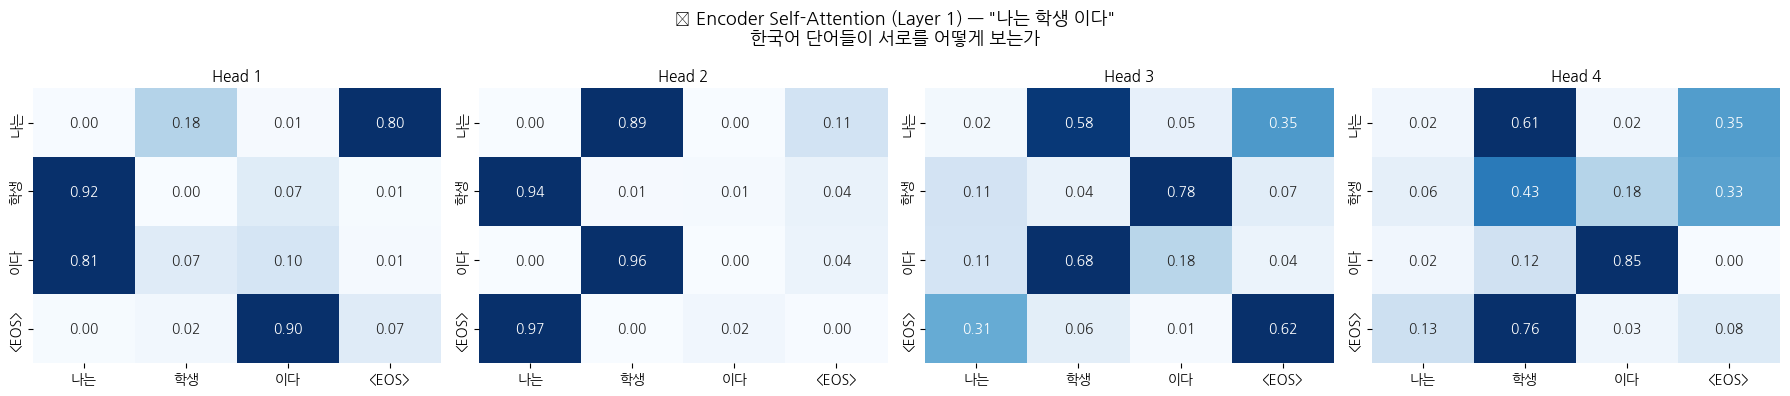

💡 해석 팁:
   • 행(세로): 질문하는 단어 (Query)
   • 열(가로): 참조하는 단어 (Key)
   • 색이 진할수록 더 많이 참조
   • 작은 데이터로 학습했기 때문에 패턴이 명확하지 않을 수 있음


In [41]:
# === 시각화 1: Encoder Self-Attention (한국어 단어들 간의 관계) ===
src_tokens = ['나는', '학생', '이다', '<EOS>']
tgt_tokens = ['<SOS>', 'I', 'am', 'a', 'student']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for h in range(4):
    ax = axes[h]
    w = enc_attns[0][0, h].cpu().numpy()
    sns.heatmap(w, annot=True, fmt='.2f',
                cmap='Blues', vmin=0, vmax=0.6,
                xticklabels=src_tokens, yticklabels=src_tokens, ax=ax,
                cbar=False, annot_kws={'size': 10})
    ax.set_title(f'Head {h+1}', fontsize=11, fontweight='bold')

plt.suptitle('🔵 Encoder Self-Attention (Layer 1) — "나는 학생 이다"\n한국어 단어들이 서로를 어떻게 보는가',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 해석 팁:')
print('   • 행(세로): 질문하는 단어 (Query)')
print('   • 열(가로): 참조하는 단어 (Key)')
print('   • 색이 진할수록 더 많이 참조')
print('   • 작은 데이터로 학습했기 때문에 패턴이 명확하지 않을 수 있음')


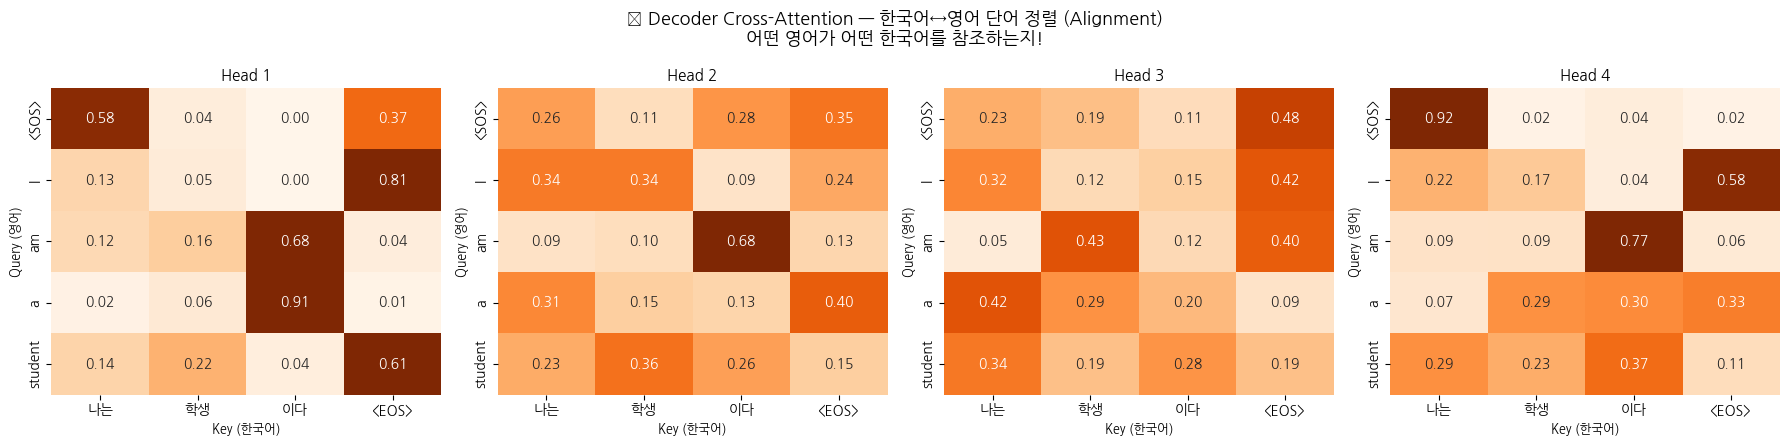

🎯 이것이 "기계 번역의 마법"의 핵심입니다!
   • 예: "student"가 "학생"에 집중하면? → 올바른 정렬!
   • 헤드마다 약간 다른 정렬 패턴을 학습

💡 실제 거대 모델에서는 이 패턴이 매우 정교합니다.


In [42]:
# === 시각화 2: Decoder Cross-Attention (소스↔타겟 연결 - 핵심!) ===
# 이게 가장 흥미롭습니다!
# 영어 단어가 한국어의 어떤 단어를 참조하는지 볼 수 있어요

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for h in range(4):
    ax = axes[h]
    w = dec_cross_attns[0][0, h].cpu().numpy()
    sns.heatmap(w, annot=True, fmt='.2f',
                cmap='Oranges', vmin=0, vmax=0.6,
                xticklabels=src_tokens, yticklabels=tgt_tokens, ax=ax,
                cbar=False, annot_kws={'size': 10})
    ax.set_title(f'Head {h+1}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Key (한국어)', fontsize=9)
    ax.set_ylabel('Query (영어)', fontsize=9)

plt.suptitle('🟠 Decoder Cross-Attention — 한국어↔영어 단어 정렬 (Alignment)\n어떤 영어가 어떤 한국어를 참조하는지!',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('🎯 이것이 "기계 번역의 마법"의 핵심입니다!')
print('   • 예: "student"가 "학생"에 집중하면? → 올바른 정렬!')
print('   • 헤드마다 약간 다른 정렬 패턴을 학습')
print('\n💡 실제 거대 모델에서는 이 패턴이 매우 정교합니다.')


---

# 1️⃣2️⃣ 현대 LLM의 핵심 개선사항 🚀

## 🎯 2017년 원본 Transformer에서 무엇이 발전했나?

ChatGPT, Claude, LLaMA, Gemini 같은 **최신 LLM**들은 원본 Transformer를 그대로 쓰지 않아요.
다음 **4가지 핵심 개선**을 거쳤습니다:

| 원본 (2017) | 현대 LLM | 개선점 |
|------------|---------|--------|
| Sinusoidal PE | **RoPE** | 더 긴 문맥 처리 |
| LayerNorm | **RMSNorm** | 더 빠른 계산 |
| ReLU FFN | **SwiGLU** | 더 좋은 성능 |
| MHA | **GQA** | 추론 시 메모리 절약 |

하나씩 살펴봅시다!


## 1️⃣ RMSNorm — 더 빠른 정규화

### 🔍 LayerNorm vs RMSNorm

**LayerNorm**: `(x - 평균) / 표준편차 * γ + β`
- 평균 계산, 표준편차 계산, 빼기, 나누기, 곱하기, 더하기 → **6단계**

**RMSNorm**: `x / √(평균(x²)) * γ`
- 제곱평균, 제곱근, 나누기, 곱하기 → **4단계**

→ **약 10% 빠르고**, 성능은 비슷!
→ LLaMA, Gemma, Mistral 등에서 사용


In [43]:
# === RMSNorm 구현 ===

class RMSNorm(nn.Module):
    """
    Root Mean Square Normalization

    RMSNorm(x) = x / RMS(x) * γ
    RMS(x) = √(mean(x²) + ε)
    """
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d_model))  # γ 학습 가능
        self.eps = eps

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x / rms * self.weight


# === 비교 실험 ===
x = torch.randn(1, 10, 512)

ln = nn.LayerNorm(512)
rmsn = RMSNorm(512)

ln_out = ln(x)
rmsn_out = rmsn(x)

print('🔬 LayerNorm vs RMSNorm 비교\n')
print(f'LayerNorm 출력  → 평균: {ln_out.mean().item():+.6f}, 표준편차: {ln_out.std().item():.4f}')
print(f'RMSNorm 출력    → 평균: {rmsn_out.mean().item():+.6f}, 표준편차: {rmsn_out.std().item():.4f}')

print(f'\n💡 차이점:')
print(f'   • LayerNorm: 평균을 0으로 강제 → 평균 ≈ 0')
print(f'   • RMSNorm: 평균은 그대로, 크기만 조정 → 약간의 평균')
print(f'   • 실제로 성능 차이는 거의 없음 + 더 빠름!')


🔬 LayerNorm vs RMSNorm 비교

LayerNorm 출력  → 평균: +0.000000, 표준편차: 1.0001
RMSNorm 출력    → 평균: -0.002174, 표준편차: 1.0001

💡 차이점:
   • LayerNorm: 평균을 0으로 강제 → 평균 ≈ 0
   • RMSNorm: 평균은 그대로, 크기만 조정 → 약간의 평균
   • 실제로 성능 차이는 거의 없음 + 더 빠름!


## 2️⃣ Rotary Position Embedding (RoPE)

### 🔍 RoPE가 뭐가 다를까?

**원본 Sinusoidal PE**: 임베딩에 위치 정보를 **더함** (덧셈)
- 한계: 학습 때 본 길이보다 긴 문장에 약함

**RoPE**: Q와 K를 **회전 변환** (곱셈)
- 장점: 매우 긴 문맥에도 잘 작동! (LLaMA의 128K 토큰 등)

### 🌀 비유: 회전하는 시계 바늘

각 위치마다 시계 바늘을 일정 각도씩 돌립니다.
- 위치 0: 0도
- 위치 1: 10도
- 위치 2: 20도
- ...

두 위치 사이의 각도 차이만 중요해져서, **상대적 위치**를 자연스럽게 학습!


In [44]:
# === RoPE 구현 ===

class RotaryPositionEmbedding(nn.Module):
    """
    Rotary Position Embedding

    Q, K를 회전 변환하여 상대적 위치 정보를 인코딩
    """
    def __init__(self, d_model, max_len=5000, base=10000):
        super().__init__()
        # 각 차원의 회전 주파수
        inv_freq = 1.0 / (base ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer('inv_freq', inv_freq)

        # 미리 모든 위치에 대해 cos/sin 계산
        t = torch.arange(max_len).float()
        freqs = torch.outer(t, inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer('cos_cached', emb.cos())
        self.register_buffer('sin_cached', emb.sin())

    def _rotate_half(self, x):
        """벡터의 절반을 교차하여 회전"""
        x1 = x[..., :x.shape[-1]//2]
        x2 = x[..., x.shape[-1]//2:]
        return torch.cat([-x2, x1], dim=-1)

    def forward(self, q, k, seq_len):
        cos = self.cos_cached[:seq_len].unsqueeze(0).unsqueeze(0)
        sin = self.sin_cached[:seq_len].unsqueeze(0).unsqueeze(0)

        q_rot = q * cos + self._rotate_half(q) * sin
        k_rot = k * cos + self._rotate_half(k) * sin
        return q_rot, k_rot


# === 실습 ===
rope = RotaryPositionEmbedding(d_model=64)

q = torch.randn(1, 4, 10, 64)
k = torch.randn(1, 4, 10, 64)

q_rot, k_rot = rope(q, k, seq_len=10)

print('🌀 RoPE 적용')
print(f'   Q 원본: {q.shape} → Q 회전: {q_rot.shape}')
print(f'   K 원본: {k.shape} → K 회전: {k_rot.shape}')

print(f'\n💡 RoPE의 강점:')
print(f'   • 학습 시 보지 못한 긴 문장에도 잘 작동')
print(f'   • LLaMA 2: 4K → LLaMA 3: 8K → 일부 모델: 128K, 1M 토큰까지!')
print(f'   • 회전 각도만 다르게 하면 무한히 확장 가능')


🌀 RoPE 적용
   Q 원본: torch.Size([1, 4, 10, 64]) → Q 회전: torch.Size([1, 4, 10, 64])
   K 원본: torch.Size([1, 4, 10, 64]) → K 회전: torch.Size([1, 4, 10, 64])

💡 RoPE의 강점:
   • 학습 시 보지 못한 긴 문장에도 잘 작동
   • LLaMA 2: 4K → LLaMA 3: 8K → 일부 모델: 128K, 1M 토큰까지!
   • 회전 각도만 다르게 하면 무한히 확장 가능


## 3️⃣ SwiGLU — 더 좋은 활성화 함수

### 🔍 SwiGLU란?

원본은 단순한 **ReLU**를 썼지만, 현대 LLM은 **SwiGLU**를 씁니다.

```
ReLU FFN:    Linear → ReLU → Linear
SwiGLU:      두 갈래로 나뉘어 한쪽은 게이트 역할 (LSTM의 gating과 유사)
```

- LLaMA, PaLM, Gemma 등에서 사용
- 같은 파라미터로 **더 좋은 성능**


In [45]:
# === SwiGLU 구현 ===

class SwiGLU(nn.Module):
    """
    SwiGLU: Swish + Gated Linear Unit

    SwiGLU(x) = (Swish(xW₁)) ⊙ (xW_gate) → W₂
    """
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff, bias=False)
        self.w2 = nn.Linear(d_ff, d_model, bias=False)
        self.w_gate = nn.Linear(d_model, d_ff, bias=False)

    def forward(self, x):
        # Swish(xW1) * (xW_gate) → 게이팅
        return self.w2(F.silu(self.w1(x)) * self.w_gate(x))


# === 비교 ===
relu_ffn = PositionwiseFeedForward(512, 2048)
swiglu_ffn = SwiGLU(512, 2048)

x_test = torch.randn(1, 10, 512)
relu_out = relu_ffn(x_test)
swiglu_out = swiglu_ffn(x_test)

print('🔬 ReLU FFN vs SwiGLU\n')
print(f'ReLU FFN  파라미터: {sum(p.numel() for p in relu_ffn.parameters()):,}')
print(f'SwiGLU    파라미터: {sum(p.numel() for p in swiglu_ffn.parameters()):,}')
print(f'\n출력 형태: {relu_out.shape} (동일)')

print(f'\n💡 SwiGLU는 게이트 매트릭스(W_gate)가 추가되어 파라미터가 1.5배 많지만,')
print(f'   같은 성능을 더 적은 파라미터로 낼 수 있음 (효율성 ↑)')


🔬 ReLU FFN vs SwiGLU

ReLU FFN  파라미터: 2,099,712
SwiGLU    파라미터: 3,145,728

출력 형태: torch.Size([1, 10, 512]) (동일)

💡 SwiGLU는 게이트 매트릭스(W_gate)가 추가되어 파라미터가 1.5배 많지만,
   같은 성능을 더 적은 파라미터로 낼 수 있음 (효율성 ↑)


## 4️⃣ Grouped-Query Attention (GQA)

### 🔍 추론(Inference) 효율성을 위한 혁신

ChatGPT가 답변할 때, **KV 캐시**라는 게 GPU 메모리를 많이 먹어요.
GQA는 이를 절약하는 기법입니다!

### 🎭 비교

| 방식 | Q 헤드 | K, V 헤드 | KV 캐시 |
|------|-------|----------|---------|
| MHA (원본) | 8 | 8 | 1x |
| **GQA (LLaMA 2/3)** | 8 | **2** | **1/4** ✨ |
| MQA (PaLM) | 8 | 1 | 1/8 |

→ GQA는 MHA만큼 성능 좋으면서 메모리 절약!


In [46]:
# === GQA 구현 ===

class GroupedQueryAttention(nn.Module):
    """
    Grouped-Query Attention

    - Q 헤드는 n_heads개
    - K, V 헤드는 n_kv_heads개 (적게!)
    - 여러 Q 헤드가 같은 K, V를 공유
    """
    def __init__(self, d_model, n_heads, n_kv_heads):
        super().__init__()
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_rep = n_heads // n_kv_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)                       # Q: 풀사이즈
        self.W_k = nn.Linear(d_model, self.n_kv_heads * self.d_k)   # K: 작게
        self.W_v = nn.Linear(d_model, self.n_kv_heads * self.d_k)   # V: 작게
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, S, _ = x.shape
        Q = self.W_q(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, S, self.n_kv_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, S, self.n_kv_heads, self.d_k).transpose(1, 2)

        # K, V를 복제해서 Q 헤드 수에 맞춤
        K = K.repeat_interleave(self.n_rep, dim=1)
        V = V.repeat_interleave(self.n_rep, dim=1)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, S, -1)
        return self.W_o(out)


# === 비교 ===
x = torch.randn(1, 10, 512)

mha = MultiHeadAttention(512, n_heads=8)
gqa = GroupedQueryAttention(512, n_heads=8, n_kv_heads=2)
mqa = GroupedQueryAttention(512, n_heads=8, n_kv_heads=1)

print('🔬 Attention 변형 비교\n')
print(f'{"방식":<25} {"Q 헤드":>8} {"KV 헤드":>8} {"KV 파라미터":>15}')
print('-' * 65)
print(f'{"MHA (원본 2017)":<25} {"8":>8} {"8":>8} {sum(p.numel() for p in [mha.W_k.weight, mha.W_v.weight]):>15,}')
print(f'{"GQA (LLaMA 2/3)":<25} {"8":>8} {"2":>8} {sum(p.numel() for p in [gqa.W_k.weight, gqa.W_v.weight]):>15,}')
print(f'{"MQA (PaLM)":<25} {"8":>8} {"1":>8} {sum(p.numel() for p in [mqa.W_k.weight, mqa.W_v.weight]):>15,}')

print(f'\n💡 GQA: KV 메모리 75% 절약!')
print(f'   → 같은 GPU로 더 긴 문맥 처리 가능')


🔬 Attention 변형 비교

방식                            Q 헤드    KV 헤드         KV 파라미터
-----------------------------------------------------------------
MHA (원본 2017)                    8        8         524,288
GQA (LLaMA 2/3)                  8        2         131,072
MQA (PaLM)                       8        1          65,536

💡 GQA: KV 메모리 75% 절약!
   → 같은 GPU로 더 긴 문맥 처리 가능


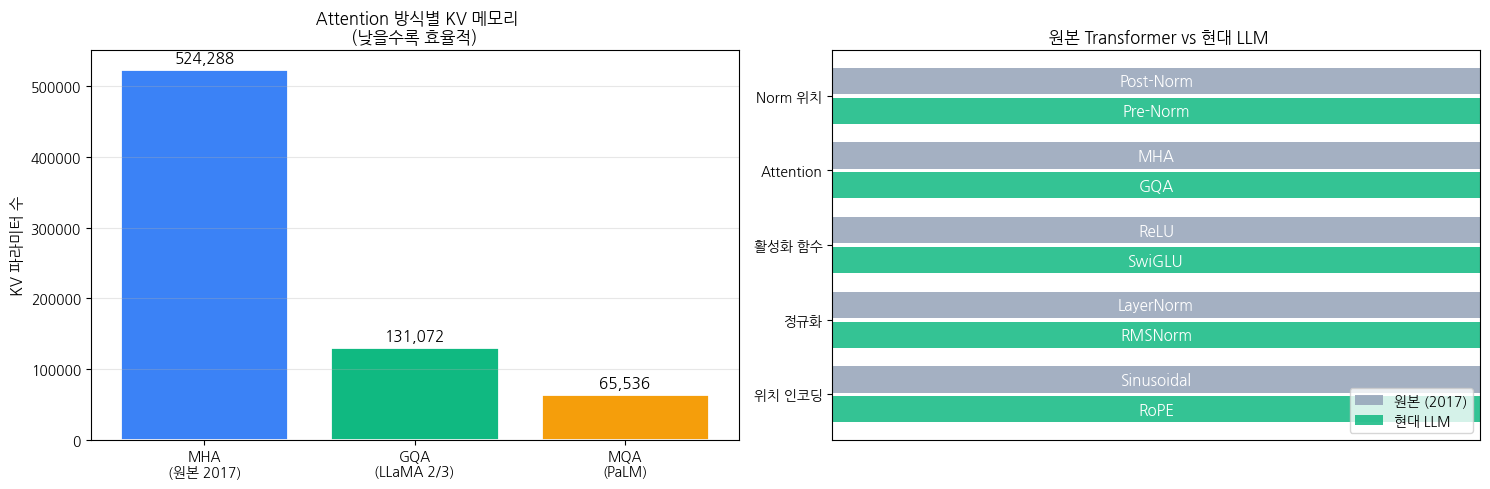

In [47]:
# === 종합 비교 시각화 ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) KV 파라미터 비교
ax = axes[0]
methods = ['MHA\n(원본 2017)', 'GQA\n(LLaMA 2/3)', 'MQA\n(PaLM)']
kv_params = [524288, 131072, 65536]
colors_kv = ['#3B82F6', '#10B981', '#F59E0B']
bars = ax.bar(methods, kv_params, color=colors_kv, edgecolor='white', linewidth=2)

for bar, val in zip(bars, kv_params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('KV 파라미터 수', fontsize=11)
ax.set_title(' Attention 방식별 KV 메모리\n(낮을수록 효율적)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# (2) 원본 vs 현대 LLM 비교 표
ax = axes[1]
categories = ['위치 인코딩', '정규화', '활성화 함수', 'Attention', 'Norm 위치']
original = ['Sinusoidal', 'LayerNorm', 'ReLU', 'MHA', 'Post-Norm']
modern = ['RoPE', 'RMSNorm', 'SwiGLU', 'GQA', 'Pre-Norm']

y_pos = np.arange(len(categories))
ax.barh(y_pos + 0.2, [1]*5, height=0.35, color='#94A3B8', label='원본 (2017)', alpha=0.85)
ax.barh(y_pos - 0.2, [1]*5, height=0.35, color='#10B981', label='현대 LLM', alpha=0.85)

for i, (orig, mod) in enumerate(zip(original, modern)):
    ax.text(0.5, i + 0.2, orig, ha='center', va='center', fontsize=11,
            color='white', fontweight='bold')
    ax.text(0.5, i - 0.2, mod, ha='center', va='center', fontsize=11,
            color='white', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(categories)
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title(' 원본 Transformer vs 현대 LLM',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


---

# 🎓 학습 완료! 핵심 정리

## 📝 우리가 배운 것들

### 🧱 기본 구성 요소

| 구성 요소 | 역할 | 핵심 수식 |
|----------|------|----------|
| **Token Embedding** | 단어 → 벡터 | `Embed(x) × √d_model` |
| **Positional Encoding** | 위치 정보 | `sin/cos(pos / 10000^(2i/d))` |
| **Self-Attention** | 토큰 간 관계 | `softmax(QK^T / √d_k) · V` |
| **Multi-Head** | 여러 관점 | `Concat(head₁,...,h) · W_O` |
| **FFN** | 정보 가공 | `max(0, xW₁+b₁)W₂+b₂` |
| **Add & Norm** | 안정화 | `LayerNorm(x + SubLayer(x))` |
| **Causal Mask** | 미래 차단 | 하삼각 행렬 |

### 🚀 현대 LLM 진화

| 원본 | 현대 | 개선점 |
|------|------|--------|
| Sinusoidal PE | **RoPE** | 긴 문맥 처리 |
| LayerNorm | **RMSNorm** | 빠른 계산 |
| ReLU | **SwiGLU** | 성능 향상 |
| MHA | **GQA** | 추론 효율 |

## 🌟 여러분이 이해한 것

이제 여러분은:
- ✅ ChatGPT, Claude, Gemini의 핵심 원리를 이해합니다
- ✅ Attention 메커니즘이 어떻게 작동하는지 압니다
- ✅ 직접 Transformer를 코드로 구현할 수 있습니다
- ✅ 작은 데이터로 번역 모델을 학습시킬 수 있습니다
- ✅ 최신 LLM 기법(RoPE, RMSNorm 등)을 이해합니다

## 🚀 다음 단계 추천

1. **🤗 Hugging Face Transformers 라이브러리** 사용해보기
   - 사전학습된 BERT, GPT 모델 활용
   - `from transformers import AutoModel`

2. **📚 큰 데이터셋으로 학습**
   - IWSLT (번역), WMT (번역)
   - 영화 리뷰 감성 분석

3. **🎯 다양한 응용**
   - 텍스트 분류, 질의응답, 요약
   - 이미지 캡션, 음악 생성

4. **🔬 최신 논문 읽기**
   - "Attention Is All You Need" (원본)
   - LLaMA, GPT-4 기술 보고서

## 💌 마지막 메시지

축하합니다! 🎉

여러분은 이제 **AI 혁명의 핵심 기술**을 이해하는 사람이 되었습니다.
이 노트북에서 만든 작은 모델과 ChatGPT는 **본질적으로 같은 원리**로 작동해요.
규모와 데이터가 다를 뿐!

> "큰 일을 하기 전에, 작은 일에서 정확한 이해를 쌓아라." - Richard Feynman

계속 호기심을 갖고 학습해 나가세요! 🚀

---

### 🙋 자주 묻는 질문

**Q1: 이걸 다 외워야 하나요?**
A: 아니요! 개념을 이해하는 것이 중요해요. 코드는 다시 찾아보면 됩니다.

**Q2: 실제로 ChatGPT 같은 걸 만들 수 있나요?**
A: 원리는 같지만, 수천억 개 파라미터와 거대 데이터셋이 필요해요.
시작은 작은 모델로! Hugging Face의 사전학습 모델을 활용하는 게 실용적입니다.

**Q3: 수학이 너무 어려워요...**
A: 코드로 보면 단순합니다! 처음엔 흐름을 이해하고, 필요할 때 수학을 다시 보세요.

---

**💝 학습해주셔서 감사합니다!**
